# Panel municipal 2/2: análisis exploratorio

Este notebook explora el panel que arma `panel_municipal_armado.ipynb`. La pregunta de fondo es sencilla:
**¿cómo son los municipios donde se deforesta, y qué tienen en común?**

Para responderla se cruzan cuatro cosas, municipio por municipio:

- **Deforestación**: la cifra oficial del IDEAM y, para comparar, las alertas de Global Forest Watch (GFW).
- **Crédito agropecuario**: los créditos de FINAGRO a pequeños y medianos productores.
- **Cultivos**: las hectáreas sembradas, según la EVA.
- **Ganado**: el número de bovinos y de fincas ganaderas, según el ICA.

Todo lo que sigue son **asociaciones**: dice qué cosas aparecen juntas, no qué causa qué.

## Cómo leer este notebook

Cada sección tiene cuatro partes:

1. **La pregunta** que intenta responder.
2. **Cómo se hace**, en palabras.
3. **Cómo leer el gráfico.**
4. **Qué muestra**, con las cifras, justo después del resultado.

In [1]:
import logging
import os
import sys
import warnings
from itertools import permutations
from pathlib import Path

# El notebook vive en notebooks/; las rutas se resuelven desde la raiz del repositorio
RAIZ = Path.cwd().resolve()
while not (RAIZ / "main_local.py").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from pipeline.config_local import DIR_DATOS, DIR_PANEL

logging.getLogger("matplotlib").setLevel(logging.WARNING)
sns.set_theme(style="whitegrid", font_scale=0.9, palette="colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 10})
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

# La tasa de deforestacion va de 0 a varios %, con la mayoria de municipios cerca de 0. En los graficos se usa
# una escala que es logaritmica arriba de 0,01 % y lineal debajo, para que el 0 quepa.
MARCAS_TASA = [0, 0.01, 0.1, 1]
TEXTO_TASA = ["0", "0,01", "0,1", "1"]


def eje_tasa(ax, eje="y"):
    getattr(ax, f"set_{eje}scale")("symlog", linthresh=0.01)
    getattr(ax, f"set_{eje}lim")(0, 8)
    getattr(ax, f"set_{eje}ticks")(MARCAS_TASA, TEXTO_TASA)


def barra_tasa(puntos, ax):
    # Barra de color para log10(tasa + 0,001), rotulada con la tasa en %
    barra = plt.colorbar(puntos, ax=ax, shrink=0.6, label="tasa de deforestación (% del bosque por año)")
    barra.set_ticks(np.log10(np.array(MARCAS_TASA) + 0.001), labels=TEXTO_TASA)

anual = pd.read_parquet(DIR_DATOS / "analisis" / "municipio_anio.parquet")
mensual = pd.read_parquet(DIR_DATOS / "analisis" / "municipio_mes.parquet")
# Ubicacion de cada municipio (promedio de sus celdas), solo para los mapas
centroides = (pd.read_parquet(DIR_PANEL / "panel_ideam.parquet", columns=["cod_dane", "periodo", "lon", "lat"])
              .query("periodo == '2020-2021'").groupby("cod_dane")[["lon", "lat"]].mean())

## 1. Las variables y la muestra

**La pregunta.** ¿Con qué datos se trabaja?

**Cómo se hace.**

- Todo se pasa a **intensidades**: la deforestación como porcentaje del bosque, el crédito y el ganado por km², los
  cultivos como porcentaje del área del municipio. La sección 6 explica por qué esto es indispensable.
- El crédito, los cultivos y el ganado se toman **del año anterior** a la deforestación: primero llega la plata o el
  ganado, después se tumba el monte.
- Se usa el crédito de **pequeños y medianos productores**. El crédito total está distorsionado: los créditos de
  empresas grandes quedan registrados en la ciudad donde está su sede, no donde está la finca.
- El crédito está en millones de pesos de cada año, sin descontar la inflación.
- Se dejan solo los municipios con **al menos 1 000 ha de bosque** según el IDEAM a comienzos de 2021. Un municipio
  sin bosque no puede deforestar, y meterlo en el análisis lo distorsiona.
- Los años son **2021 a 2025**, los que tienen dato del IDEAM.
- Cada municipio aparece cinco veces, una por año, y esas cinco filas se parecen mucho. Para comparar municipios se
  usa **una fila por municipio, con el promedio de sus cinco años**: así cada municipio cuenta una vez.

In [2]:
km2 = anual.area_grilla_ha / 100
d = anual.assign(
    # Deforestacion del anio
    tasa=100 * anual.tasa_def_ideam,                                    # % del bosque perdido en el anio
    def_100km2=100 * anual.def_ideam_ha / km2,                          # ha deforestadas por 100 km2
    gfw_100km2=100 * anual.alertas_gfw_ha / km2,                        # ha en alerta GFW por 100 km2
    # Explicativas del anio anterior
    cred_pm=anual.credito_pequeno_mediano_mm_t1 / km2,                  # millones de pesos por km2
    cred_gan=anual.credito_ganaderia_pequeno_mediano_mm_t1 / km2,
    bovinos=anual.bovinos_t1 / km2,                                     # animales por km2
    fincas=100 * anual.fincas_bovinas_t1 / km2,                         # fincas por 100 km2
    agricola=100 * anual.area_sembrada_ha_t1 / anual.area_grilla_ha,    # % del area del municipio
    palma=100 * anual.sembrada_palma_ha_t1 / anual.area_grilla_ha,
    cacao=100 * anual.sembrada_cacao_ha_t1 / anual.area_grilla_ha,
    cafe=100 * anual.sembrada_cafe_ha_t1 / anual.area_grilla_ha,
    arroz=100 * anual.sembrada_arroz_ha_t1 / anual.area_grilla_ha,
    # Caracteristicas fijas del municipio
    bosque=100 * anual.bosque_ideam_inicial_ha / anual.area_grilla_ha,  # % del municipio con bosque en 2021
    area=km2,
).replace([np.inf, -np.inf], np.nan)

VARIABLES = ["cred_pm", "cred_gan", "bovinos", "fincas", "agricola", "palma", "cacao", "cafe", "arroz",
             "bosque", "area"]
NOMBRES = {
    "tasa": "Deforestación IDEAM (% del bosque)",
    "def_100km2": "Deforestación IDEAM (ha / 100 km²)", "gfw_100km2": "Alertas GFW (ha / 100 km²)",
    "cred_pm": "Crédito peq. y medianos (M$ / km²)", "cred_gan": "Crédito ganadero peq. y med. (M$ / km²)",
    "bovinos": "Bovinos por km²", "fincas": "Fincas ganaderas por 100 km²",
    "agricola": "Área sembrada (% del municipio)", "palma": "Palma (% del municipio)",
    "cacao": "Cacao (% del municipio)", "cafe": "Café (% del municipio)", "arroz": "Arroz (% del municipio)",
    "bosque": "Bosque (% del municipio)", "area": "Área del municipio (km²)",
}
# Nombres cortos, para tablas y graficos con poco espacio
CORTOS = {"tasa": "deforestación", "cred_pm": "crédito", "cred_gan": "crédito ganadero", "bovinos": "bovinos",
          "fincas": "fincas", "agricola": "área sembrada", "palma": "palma", "cacao": "cacao", "cafe": "café",
          "arroz": "arroz", "bosque": "bosque", "area": "área"}

muestra = d[(d.bosque_ideam_inicial_ha >= 1000) & d.anio.between(2021, 2025)].copy()

# Una fila por municipio: el promedio de 2021-2025 (y el total, para las hectareas)
municipios = (muestra.groupby("cod_dane")
              .agg(**{c: (c, "mean") for c in ["tasa", "def_100km2", "gfw_100km2"] + VARIABLES},
                   def_total_ha=("def_ideam_ha", "sum"), gfw_total_ha=("alertas_gfw_ha", "sum"),
                   nombre=("nombre_municipio", "first"), departamento=("nombre_departamento", "first"),
                   region=("region", "first"))
              .join(centroides))

print(f"Municipios en el panel: {anual.cod_dane.nunique():,}")
print(f"Con al menos 1 000 ha de bosque: {len(municipios):,}  ({len(muestra):,} filas municipio-año)")
pd.DataFrame({"variable": [NOMBRES[c] for c in ["tasa"] + VARIABLES],
              "fuente": ["IDEAM", "FINAGRO", "FINAGRO", "ICA", "ICA", "EVA", "EVA", "EVA", "EVA", "EVA",
                         "IDEAM", "Grilla de 5 km"],
              "año": ["el del análisis"] + ["el anterior"] * 9 + ["2021 (fijo)", "fijo"]}).set_index("variable")

Municipios en el panel: 1,123
Con al menos 1 000 ha de bosque: 777  (3,885 filas municipio-año)


,fuente,año
variable,,
Deforestación IDEAM (% del bosque),IDEAM,el del análisis
Crédito peq. y medianos (M$ / km²),FINAGRO,el anterior
Crédito ganadero peq. y med. (M$ / km²),FINAGRO,el anterior
Bovinos por km²,ICA,el anterior
Fincas ganaderas por 100 km²,ICA,el anterior
Área sembrada (% del municipio),EVA,el anterior
Palma (% del municipio),EVA,el anterior
Cacao (% del municipio),EVA,el anterior
Café (% del municipio),EVA,el anterior


Las regiones son las de la tabla de municipios del Observatorio. Esta tabla dice qué departamentos tiene cada una,
con cuántos municipios de la muestra.

In [3]:
pd.DataFrame({
    "municipios en la muestra": municipios.region.value_counts(),
    "departamentos": municipios.groupby("region").departamento.apply(
        lambda s: ", ".join(f"{d} ({n})" for d, n in s.astype(str).value_counts().items())),
}).sort_values("municipios en la muestra", ascending=False).style.set_properties(**{"text-align": "left"})

,municipios en la muestra,departamentos
region,,
Centro Oriente,233,"Santander (68), Cundinamarca (65), Boyacá (61), Norte de Santander (38), Bogotá, D.C. (1)"
Eje cafetero,138,"Antioquia (108), Caldas (16), Risaralda (8), Quindío (6)"
Pacífico,130,"Nariño (42), Chocó (30), Cauca (29), Valle del Cauca (29)"
Centro Sur,108,"Tolima (41), Huila (29), Caquetá (15), Putumayo (12), Amazonas (11)"
Caribe,91,"Bolívar (25), Cesar (18), La Guajira (15), Magdalena (14), Córdoba (11), Sucre (8)"
Llano,76,"Meta (28), Casanare (19), Guainía (8), Arauca (7), Vaupés (6), Guaviare (4), Vichada (4)"


## 2. Cómo se distribuye cada variable

**La pregunta.** ¿Qué valores toma cada variable? ¿Hay muchos ceros? ¿Unos pocos municipios con valores enormes?

**Cómo se hace.** Histogramas, con una fila por municipio. Primero la tasa de deforestación en escala normal y en
escala logarítmica, para ver por qué hace falta la segunda. Después todas las variables en escala logarítmica.

**Cómo leer el gráfico.** Cada barra cuenta cuántos municipios tienen valores en ese rango. El título dice qué
porcentaje de municipios tiene cero.

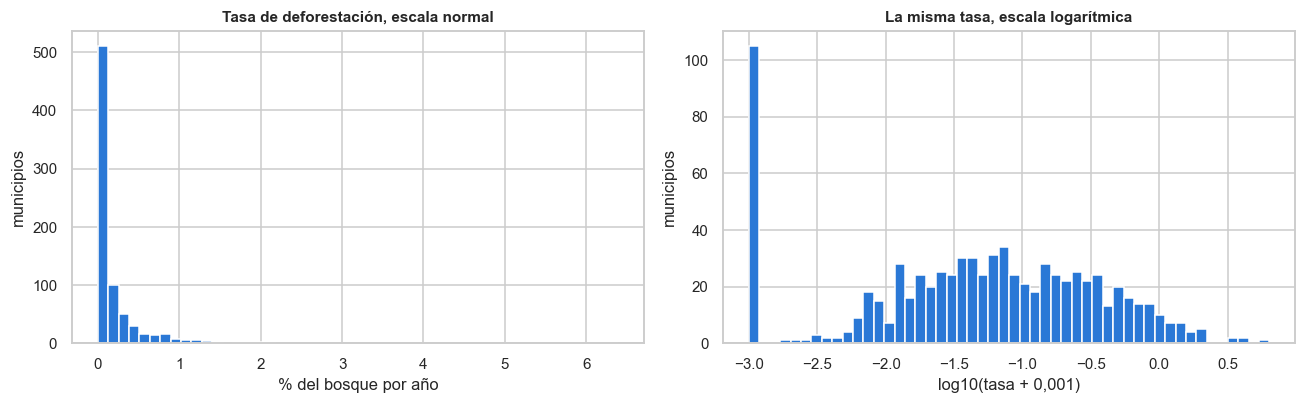

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.hist(municipios.tasa, bins=50, color="#2a78d6")
a1.set(title="Tasa de deforestación, escala normal", xlabel="% del bosque por año", ylabel="municipios")
a2.hist(np.log10(municipios.tasa + 0.001), bins=50, color="#2a78d6")
a2.set(title="La misma tasa, escala logarítmica", xlabel="log10(tasa + 0,001)", ylabel="municipios")
plt.tight_layout()
plt.show()

<!-- lectura:2a -->
**Qué muestra.** En escala normal casi todo se amontona cerca de cero. El municipio típico pierde el 0,055 % de su
bosque al año; el 62 % de los municipios pierde menos de 0,1 % y solo el 4 % pierde más de 1 %. El máximo es El Guamo
(Bolívar), con 6,4 % al año.

En escala logarítmica se ven bien los municipios con tasas pequeñas, que en la escala normal quedan aplastados
contra el cero. La barra suelta de la izquierda son los municipios que no perdieron nada en los cinco años: el 13 %.

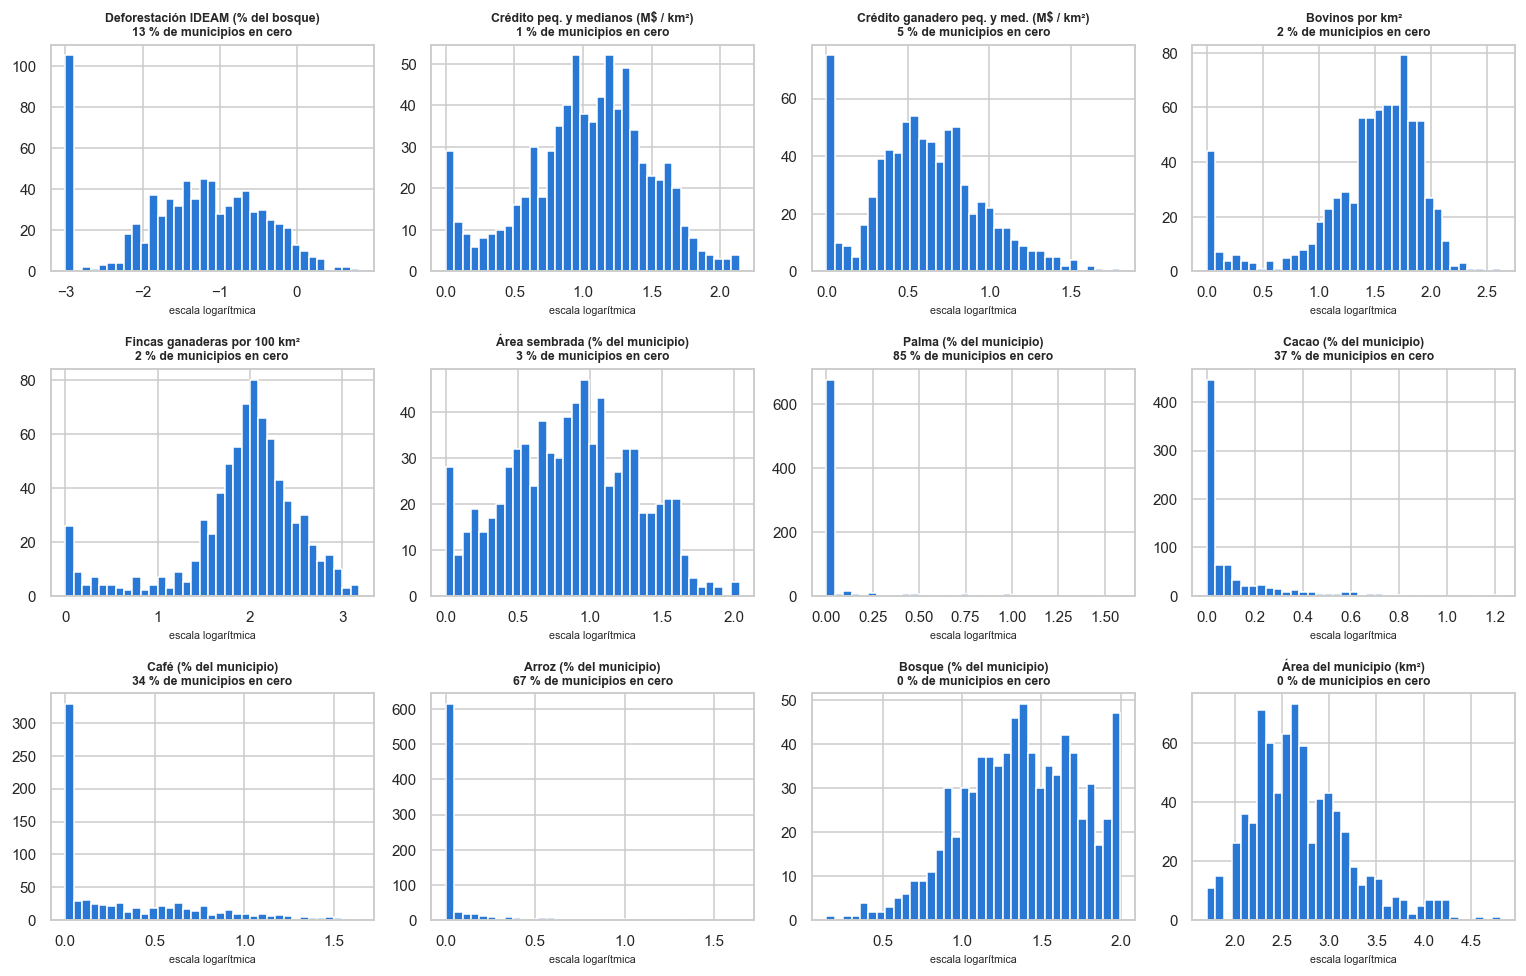

In [5]:
columnas = ["tasa"] + VARIABLES
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for ax, c in zip(axes.flat, columnas):
    v = municipios[c].dropna()
    ax.hist(np.log10(v + (0.001 if c == "tasa" else 1)), bins=35, color="#2a78d6")
    ax.set_title(f"{NOMBRES[c]}\n{100 * (v == 0).mean():.0f} % de municipios en cero", fontsize=8)
    ax.set_xlabel("escala logarítmica", fontsize=7)
for ax in axes.flat[len(columnas):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

<!-- lectura:2b -->
**Qué muestra.**

- El crédito, el ganado, las fincas, el área sembrada, el bosque y el área del municipio tienen pocos ceros y, en
  escala logarítmica, forma de campana. Por eso el PCA y el k-medias los usan en esa escala.
- La palma, el arroz, el cacao y el café son cultivos de pocos municipios: el 85 % no tiene palma, el 67 % no tiene
  arroz, el 37 % no tiene cacao y el 34 % no tiene café. Con tantos ceros, la correlación de esos cultivos dice sobre
  todo si el municipio **tiene o no** el cultivo.

## 3. Cómo cambió todo en el país, año a año

**La pregunta.** ¿La deforestación, el crédito y el ganado suben o bajan en el tiempo? ¿Se mueven juntos?

**Cómo se hace.** Se suma cada variable sobre todos los municipios del país, año por año.

**Cómo leer los gráficos.** Arriba, las hectáreas deforestadas según el IDEAM y las alertas de GFW. Abajo, cada
variable como **índice con 2021 = 100**: un valor de 120 quiere decir 20 % más que en 2021. Así se pueden comparar
en un mismo gráfico cosas que se miden en unidades muy distintas.

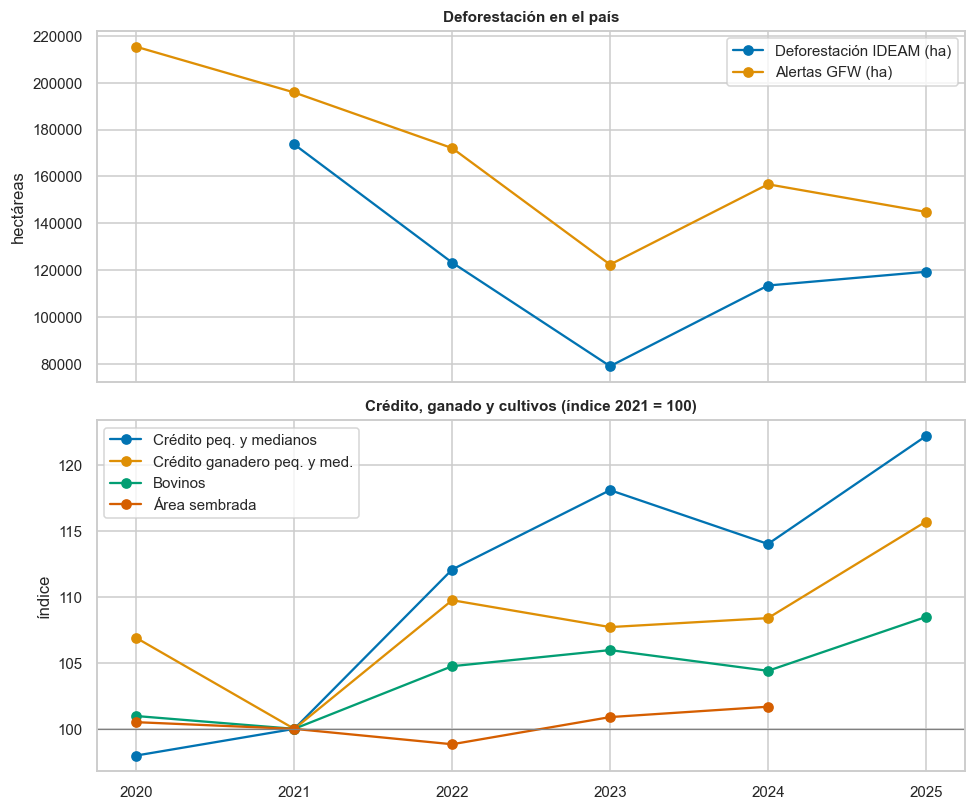

,Deforestación IDEAM (ha),Alertas GFW (ha),Crédito peq. y medianos,Crédito ganadero peq. y med.,Bovinos,Área sembrada
anio,,,,,,
2020,NaN,215345.0,5960525.0,2133940.0,28245262.0,5452215.0
2021,173663.0,195833.0,6083314.0,1996437.0,27973390.0,5424696.0
2022,123204.0,172082.0,6817612.0,2190992.0,29301392.0,5361493.0
2023,78982.0,122362.0,7183331.0,2150348.0,29642539.0,5473092.0
2024,113423.0,156640.0,6935222.0,2163926.0,29203256.0,5515725.0
2025,119282.0,144843.0,7432262.0,2309837.0,30344182.0,NaN


In [6]:
total = anual.groupby("anio")[["def_ideam_ha", "alertas_gfw_ha", "credito_pequeno_mediano_mm",
                               "credito_ganaderia_pequeno_mediano_mm", "bovinos", "area_sembrada_ha"]].sum(min_count=1)
total.loc[2020, "def_ideam_ha"] = np.nan        # el IDEAM no tiene 2020
total.loc[2025, "area_sembrada_ha"] = np.nan    # la EVA no tiene 2025
total.columns = ["Deforestación IDEAM (ha)", "Alertas GFW (ha)", "Crédito peq. y medianos",
                 "Crédito ganadero peq. y med.", "Bovinos", "Área sembrada"]

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 7.5), sharex=True)
total.iloc[:, :2].plot(ax=a1, marker="o")
a1.set(title="Deforestación en el país", ylabel="hectáreas")
(100 * total.iloc[:, 2:] / total.iloc[:, 2:].loc[2021]).plot(ax=a2, marker="o")
a2.axhline(100, color="grey", lw=0.8)
a2.set(title="Crédito, ganado y cultivos (índice 2021 = 100)", ylabel="índice", xlabel="")
plt.tight_layout()
plt.show()
total.round(0)

<!-- lectura:3 -->
**Qué muestra.**

- La deforestación del IDEAM bajó a menos de la mitad entre 2021 y 2023 (de 173 663 a 78 982 ha) y volvió a subir
  hasta 119 282 ha en 2025. Las alertas de GFW dibujan la misma curva, siempre por encima.
- El crédito a pequeños y medianos creció 22 % entre 2021 y 2025 y el ganadero 16 %. Son pesos de cada año: solo la
  inflación de 2022 a 2024 sumó cerca de 30 %, así que en pesos de igual valor el crédito no creció.
- Los bovinos crecieron 8 % y el área sembrada casi no cambió.
- En el país, la deforestación y el crédito no se movieron juntos: en 2022 y 2023 el crédito subió mientras la
  deforestación caía. Con solo cinco años no se puede sacar mucho más de aquí; el resto del notebook compara
  municipios.

## 4. Dónde se concentra la deforestación

**La pregunta.** ¿La deforestación está repartida en muchos municipios o concentrada en pocos? ¿En qué regiones?

**Cómo se hace.**

- Una **curva de Lorenz** y el **coeficiente de Gini** para la deforestación total 2021–2025 de cada municipio, y
  para el crédito y el ganado, como comparación.
- La lista de los municipios que más deforestan.
- Un resumen por región y un **boxplot** de la tasa de deforestación por región.

**Cómo leer la curva de Lorenz.** Los municipios se ordenan de mayor a menor. El eje horizontal dice qué
porcentaje de municipios se lleva, y el vertical qué porcentaje del total suman. Si todos aportaran lo mismo, la
curva sería la diagonal; mientras más se despega hacia arriba, más concentrado está.

**Cómo leer el boxplot.** La caja va del municipio que está en el 25 % al que está en el 75 %; la raya del medio es la
mediana; los puntos sueltos son municipios atípicos. El eje de la tasa salta de 10 en 10 (0,01 → 0,1 → 1 %), para
que quepan a la vez los municipios con tasas mínimas y los de tasas altas. Este eje se usa en todos los boxplots.

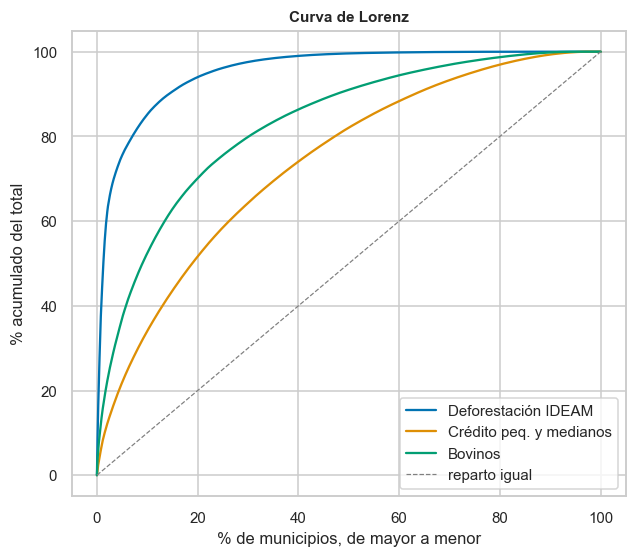

,Gini,municipios que suman el 50 %,municipios que suman el 80 %
variable,,,
Deforestación IDEAM,0.91,10,55
Crédito peq. y medianos,0.48,147,367
Bovinos,0.66,71,235


In [7]:
sumas = muestra.groupby("cod_dane")[["def_ideam_ha", "credito_pequeno_mediano_mm_t1", "bovinos_t1"]].sum()
etiquetas = {"def_ideam_ha": "Deforestación IDEAM", "credito_pequeno_mediano_mm_t1": "Crédito peq. y medianos",
             "bovinos_t1": "Bovinos"}


def gini(v):
    v = np.sort(np.asarray(v, float))
    n = len(v)
    return (2 * np.arange(1, n + 1) - n - 1) @ v / (n * v.sum())


fig, ax = plt.subplots(figsize=(6.5, 5.5))
filas = []
for c, nombre in etiquetas.items():
    v = np.sort(sumas[c].clip(lower=0).values)[::-1]
    acumulado = np.r_[0, np.cumsum(v) / v.sum()]
    ax.plot(np.linspace(0, 100, len(acumulado)), 100 * acumulado, label=nombre)
    filas.append({"variable": nombre, "Gini": round(gini(v), 2),
                  "municipios que suman el 50 %": int(np.argmax(acumulado >= .5)),
                  "municipios que suman el 80 %": int(np.argmax(acumulado >= .8))})
ax.plot([0, 100], [0, 100], color="grey", lw=0.8, ls="--", label="reparto igual")
ax.set(title="Curva de Lorenz", xlabel="% de municipios, de mayor a menor", ylabel="% acumulado del total")
ax.legend()
plt.show()
pd.DataFrame(filas).set_index("variable")

<!-- lectura:4a -->
**Qué muestra.** La deforestación está mucho más concentrada que el crédito o el ganado. Su Gini es 0,91: **10
municipios suman la mitad** de toda la deforestación de 2021–2025, y 55 suman el 80 %. El crédito (Gini 0,48)
necesita 147 municipios para llegar a la mitad, y los bovinos (Gini 0,66), 71. En la curva, la línea de la
deforestación sube casi en vertical.

In [8]:
top = municipios.sort_values("def_total_ha", ascending=False).head(15)
top = top.assign(**{"% del total": 100 * top.def_total_ha / municipios.def_total_ha.sum()})
(top[["nombre", "departamento", "region", "def_total_ha", "% del total", "tasa"]]
 .rename(columns={"def_total_ha": "hectáreas 2021-2025", "tasa": "tasa promedio (%/año)"}).round(2))

,nombre,departamento,region,hectáreas 2021-2025,% del total,tasa promedio (%/año)
cod_dane,,,,,,
18150,Cartagena del Chairá,Caquetá,Centro Sur,55725.31,9.18,1.32
18753,San Vicente del Caguán,Caquetá,Centro Sur,44512.44,7.33,0.77
50325,Mapiripán,Meta,Llano,34891.38,5.75,1.18
50350,La Macarena,Meta,Llano,32949.69,5.43,1.83
95015,Calamar,Guaviare,Llano,30142.94,4.96,0.50
95001,San José del Guaviare,Guaviare,Llano,29724.00,4.89,0.47
18756,Solano,Caquetá,Centro Sur,21367.94,3.52,0.11
86571,Puerto Guzmán,Putumayo,Centro Sur,19865.75,3.27,1.56
54810,Tibú,Norte de Santander,Centro Oriente,18858.38,3.11,3.39


<!-- lectura:4b -->
**Qué muestra.** Estos 15 municipios suman el 61 % de la deforestación. Casi todos están en el arco amazónico:
Caquetá, Meta, Guaviare y Putumayo. La excepción es Tibú, en el Catatumbo. Cartagena del Chairá y San Vicente del
Caguán, solos, suman el 16,5 %.

Las hectáreas y la tasa responden preguntas diferentes. Solano deforestó 21 368 ha, pero su tasa es 0,11 % porque
tiene muchísimo bosque. Tibú deforestó un poco menos, 18 858 ha, y perdió el 3,4 % de su bosque cada año.

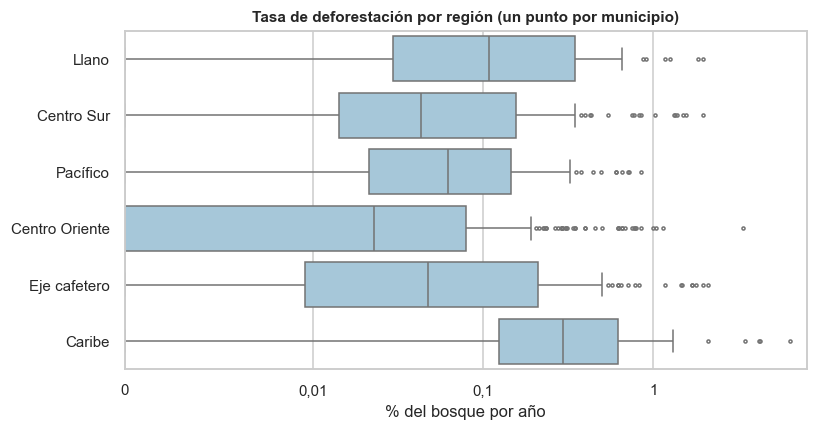

,municipios,hectareas,% de las hectáreas,tasa de la región (%/año),tasa del municipio típico (%/año)
region,,,,,
Llano,76,248870.31,41.09,0.21,0.11
Centro Sur,108,181473.81,29.96,0.18,0.04
Pacífico,130,60816.62,10.04,0.15,0.06
Centro Oriente,233,43680.62,7.21,0.35,0.02
Eje cafetero,138,43195.25,7.13,0.35,0.05
Caribe,91,27634.12,4.56,0.32,0.30


In [9]:
por_region = (muestra.groupby("region")
              .agg(municipios=("cod_dane", "nunique"), hectareas=("def_ideam_ha", "sum"), bosque=("bosque_ideam_ha", "sum"))
              .assign(**{"% de las hectáreas": lambda t: 100 * t.hectareas / t.hectareas.sum(),
                         "tasa de la región (%/año)": lambda t: 100 * t.hectareas / t.bosque})
              .join(municipios.groupby("region").tasa.median().rename("tasa del municipio típico (%/año)"))
              .drop(columns="bosque").sort_values("hectareas", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=municipios, x="tasa", y="region", order=por_region.index, color="#9ecae1", fliersize=2, ax=ax)
eje_tasa(ax, "x")
ax.set(title="Tasa de deforestación por región (un punto por municipio)", xlabel="% del bosque por año", ylabel="")
plt.show()
por_region.round(2)

<!-- lectura:4c -->
**Qué muestra.**

- El Llano y Centro Sur suman el **71 %** de las hectáreas deforestadas.
- La tasa cuenta otra historia. En el Caribe el municipio típico pierde el 0,30 % de su bosque al año, la tasa más
  alta, aunque la región solo pone el 4,6 % de las hectáreas: tiene poco bosque y lo pierde rápido. En el Llano el
  municipio típico pierde 0,11 %.
- La "tasa de la región" suma todas las hectáreas perdidas y las divide por todo el bosque de la región. En Centro
  Oriente es 0,35 %, mucho más que la del municipio típico (0,02 %): la sube un puñado de municipios con tasas muy
  altas, como Tibú. Son los puntos sueltos a la derecha en el boxplot.
- En el mapa, los municipios con tasas altas (rojos) se ven en el Caribe, el Magdalena Medio y el Catatumbo, y en el
  piedemonte de Meta, Caquetá y Putumayo. La zona andina central (amarillo claro) casi no deforesta. Los municipios
  más apartados de la Amazonía tienen tasas bajas: pierden mucho en hectáreas, pero poco frente a todo el bosque que
  tienen.

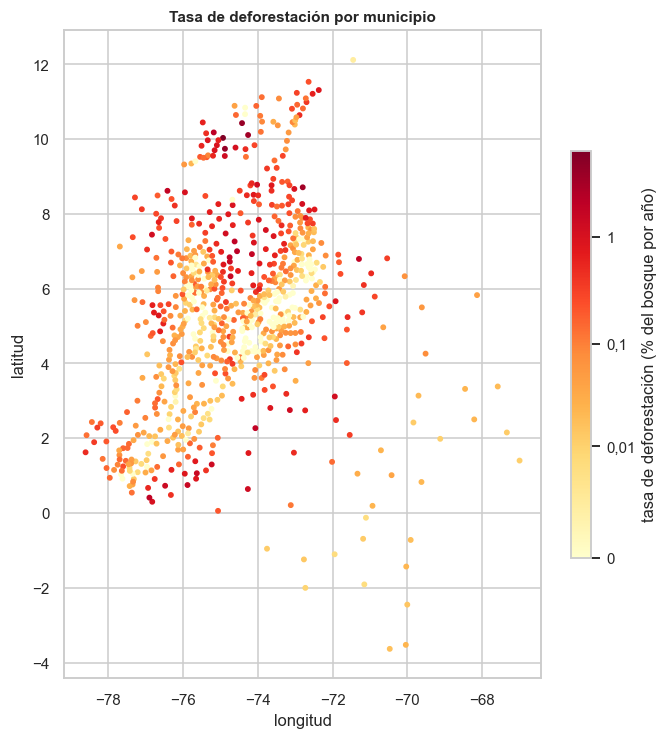

In [10]:
fig, ax = plt.subplots(figsize=(7, 8))
p = municipios.dropna(subset=["lon", "lat"])
puntos = ax.scatter(p.lon, p.lat, c=np.log10(p.tasa + 0.001), cmap="YlOrRd", s=8)
barra_tasa(puntos, ax)
ax.set(title="Tasa de deforestación por municipio", xlabel="longitud", ylabel="latitud")
ax.set_aspect("equal")
plt.show()

## 5. ¿Coinciden el IDEAM y GFW?

**La pregunta.** Las dos fuentes miden la deforestación de forma distinta. ¿Dicen lo mismo?

**Cómo se hace.** Se compara el total 2021–2025 de cada municipio en las dos fuentes, con la **correlación de
Spearman** (¿ordenan igual a los municipios?) y la **concordancia de Lin** (¿dan los mismos números?).

**Cómo leer el gráfico.** Cada punto es un municipio. Si las dos fuentes coincidieran exactamente, los puntos caerían
sobre la línea punteada. Los ejes están en escala logarítmica.

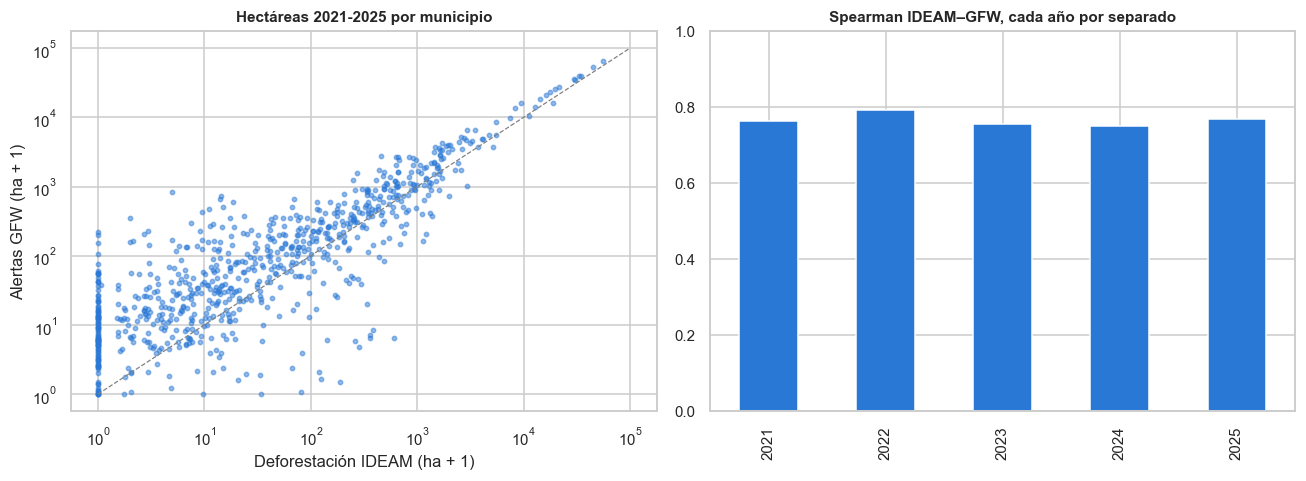

,valor
Spearman,0.81
"Spearman, el peor año",0.75
"Spearman, el mejor año",0.79
Lin (en escala logarítmica),0.78
"GFW suma, frente al IDEAM",1.30


In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.scatter(municipios.def_total_ha + 1, municipios.gfw_total_ha + 1, s=8, alpha=.5, color="#2a78d6")
a1.plot([1, 1e5], [1, 1e5], color="grey", ls="--", lw=0.8)
a1.set(xscale="log", yscale="log", title="Hectáreas 2021-2025 por municipio",
       xlabel="Deforestación IDEAM (ha + 1)", ylabel="Alertas GFW (ha + 1)")
por_anio = muestra.groupby("anio").apply(lambda g: g.def_ideam_ha.corr(g.alertas_gfw_ha, method="spearman"))
por_anio.plot.bar(ax=a2, color="#2a78d6")
a2.set(title="Spearman IDEAM–GFW, cada año por separado", xlabel="", ylim=(0, 1))
plt.tight_layout()
plt.show()


def lin(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    return 2 * np.cov(x, y, bias=True)[0, 1] / (x.var() + y.var() + (x.mean() - y.mean()) ** 2)


pd.Series({
    "Spearman": municipios.def_total_ha.corr(municipios.gfw_total_ha, method="spearman"),
    "Spearman, el peor año": por_anio.min(),
    "Spearman, el mejor año": por_anio.max(),
    "Lin (en escala logarítmica)": lin(np.log1p(municipios.def_total_ha), np.log1p(municipios.gfw_total_ha)),
    "GFW suma, frente al IDEAM": municipios.gfw_total_ha.sum() / municipios.def_total_ha.sum(),
}).round(2).to_frame("valor")

<!-- lectura:5 -->
**Qué muestra.**

- Las dos fuentes ordenan a los municipios de forma muy parecida: Spearman de 0,81. Año por año da entre 0,75 y
  0,79, así que el acuerdo es estable.
- También dan números parecidos: Lin de 0,78 en escala logarítmica. Los municipios que más deforestan caen casi
  sobre la línea punteada.
- GFW suma 30 % más que el IDEAM. GFW puede marcar alertas fuera de lo que el IDEAM cuenta como bosque natural, y una
  alerta no siempre termina siendo deforestación.
- Las diferencias están en los municipios con poca deforestación. La columna de puntos pegada a la izquierda son 100
  municipios donde el IDEAM no registra deforestación en cinco años y GFW sí marca alertas, casi siempre pocas
  hectáreas.
- **Para el resto del análisis:** las dos fuentes sirven para saber **dónde** se deforesta. Para las hectáreas se usa
  el IDEAM, que es la cifra oficial; GFW se usa en la escala mensual (secciones 12 y 13), porque el IDEAM no tiene
  datos por mes.

## 6. Por qué todo va "por km²"

**La pregunta.** ¿Qué pasa si se comparan totales, sin tener en cuenta el tamaño del municipio?

**Cómo se hace.** Se calcula la correlación de cada variable con el área del municipio, primero en total (hectáreas,
número de bovinos, millones de pesos) y después por km².

**Cómo leer la tabla.** Si una variable en total se correlaciona mucho con el área, comparar totales es en buena
parte comparar tamaños. Un municipio diez veces más grande tiene, sin más, más ganado, más crédito y más hectáreas
deforestadas.

In [12]:
pares = {"Deforestación": ("def_ideam_ha", "def_100km2"),
         "Crédito peq. y medianos": ("credito_pequeno_mediano_mm_t1", "cred_pm"),
         "Bovinos": ("bovinos_t1", "bovinos"),
         "Área sembrada": ("area_sembrada_ha_t1", "agricola")}
pd.DataFrame({nombre: {"en total, con el área": muestra[t].corr(muestra.area, method="spearman"),
                       "por km², con el área": muestra[i].corr(muestra.area, method="spearman")}
              for nombre, (t, i) in pares.items()}).T.round(2)

,"en total, con el área","por km², con el área"
Deforestación,0.74,0.56
Crédito peq. y medianos,0.22,-0.67
Bovinos,0.42,-0.32
Área sembrada,0.34,-0.43


<!-- lectura:6 -->
**Qué muestra.**

- En totales, la deforestación tiene una correlación de 0,74 con el área del municipio. Buena parte de "deforesta
  más" es "es más grande".
- Al pasar a km², el crédito, los bovinos y el área sembrada cambian de signo: los municipios grandes tienen
  **menos** de todo por km² (−0,67 en el caso del crédito). Son municipios apartados, con mucho territorio y poca
  actividad.
- La deforestación por km² sigue asociada al área (0,56): los municipios grandes de verdad deforestan más por km².
  Por eso el área del municipio se deja como una variable más.

## 7. Correlaciones

Esta es la sección central del notebook. Responde dos preguntas:

1. ¿Los municipios con más crédito, ganado o cultivos son los que más deforestan?
2. ¿Cómo se relacionan el crédito, el ganado y los cultivos entre sí?

### Cómo leer una correlación

- **Qué mide.** La correlación de Spearman va de −1 a 1. Positiva: cuando una variable es alta, la otra también
  tiende a serlo. Negativa: cuando una es alta, la otra tiende a ser baja. Cero: no hay relación.
- **Qué tan grande es.** Una guía usual para el valor sin signo:

  | Valor | Se lee como |
  |---|---|
  | menos de 0,1 | nada |
  | 0,1 a 0,3 | débil |
  | 0,3 a 0,5 | moderada |
  | más de 0,5 | fuerte |

- **¿Puede ser casualidad?** Se revisa de dos formas:
  - Con un **intervalo de confianza del 95 % por bootstrap**: se repite el cálculo 1 000 veces, cada vez con una
    muestra de municipios escogidos al azar, y se toma el rango donde caen 95 de cada 100 resultados. Si el intervalo
    cruza el cero, no se puede afirmar que haya relación.


### Cómo se calculan correlaciones con datos que cambian en el tiempo

Cada municipio aparece cinco veces, una por año (2021 a 2025). Con datos así hay tres formas de calcular una
correlación, y cada una responde una pregunta distinta. El notebook usa las tres:

| Forma | Qué se compara | Pregunta que responde | Dónde está |
|---|---|---|---|
| **Promedio de los cinco años** | Un municipio contra otro. Cada municipio es una fila, con el promedio de sus cinco años. | ¿En qué tipo de municipio se deforesta más? | 7.1 a 7.4, 7.7 y 7.8 |
| **Año por año** | Un municipio contra otro, dentro de un mismo año. Se calcula una correlación por año. | ¿La relación se repite todos los años? | 7.5 |
| **Cambios dentro del municipio** | Un año contra otro, dentro del mismo municipio. | Cuando algo sube en un municipio, ¿sube también su deforestación? | 11 |

En la escala mensual se usa, además, la correlación con rezagos (sección 13).

**Por qué no se juntan las 3 885 filas en una sola correlación.** Las cinco filas de un municipio son casi iguales,
porque el crédito, el ganado y los cultivos casi no cambian de un año a otro (sección 11). Juntarlas sería contar
cinco veces el mismo municipio: .
**El año anterior.** En las tres formas, el crédito, los cultivos y el ganado se toman del año anterior a la
deforestación.

### 7.1 Cada variable frente a la deforestación

**Cómo leer el gráfico.** Cada punto es la correlación con la tasa de deforestación y la línea, su intervalo.

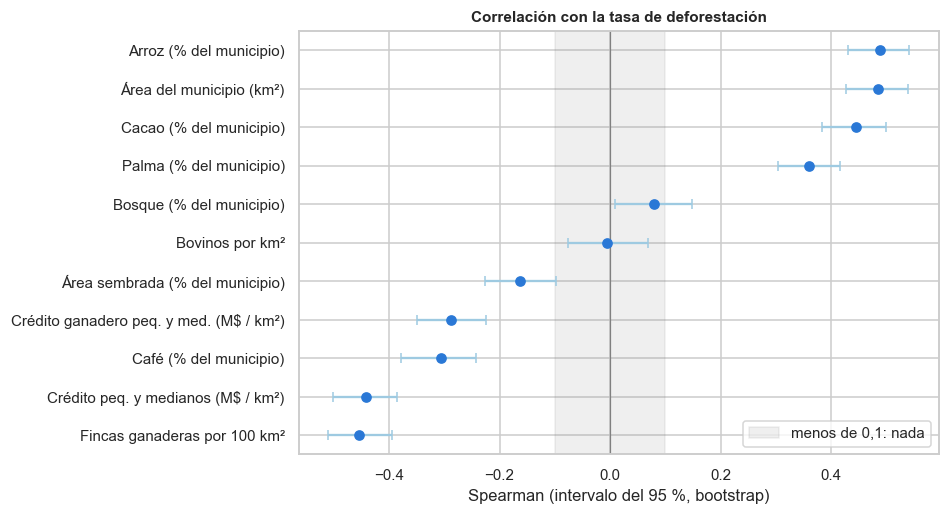

,Spearman,desde,hasta
Fincas ganaderas por 100 km²,-0.46,-0.51,-0.40
Crédito peq. y medianos (M$ / km²),-0.44,-0.50,-0.39
Café (% del municipio),-0.31,-0.38,-0.24
Crédito ganadero peq. y med. (M$ / km²),-0.29,-0.35,-0.22
Área sembrada (% del municipio),-0.16,-0.23,-0.10
Bovinos por km²,-0.01,-0.08,0.07
Bosque (% del municipio),0.08,0.01,0.15
Palma (% del municipio),0.36,0.30,0.42
Cacao (% del municipio),0.44,0.38,0.50
Área del municipio (km²),0.49,0.43,0.54


In [13]:
columnas = ["tasa"] + VARIABLES
base = municipios[columnas].corr(method="spearman")["tasa"][VARIABLES]
rng = np.random.default_rng(0)
replicas = pd.DataFrame([
    municipios[columnas].iloc[rng.integers(0, len(municipios), len(municipios))]
    .corr(method="spearman")["tasa"][VARIABLES] for _ in range(1000)])
correlaciones = pd.DataFrame({"Spearman": base, "desde": replicas.quantile(.025),
                              "hasta": replicas.quantile(.975)}).sort_values("Spearman")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.errorbar(correlaciones.Spearman, range(len(correlaciones)),
            xerr=[correlaciones.Spearman - correlaciones.desde, correlaciones.hasta - correlaciones.Spearman],
            fmt="o", color="#2a78d6", ecolor="#9ecae1", capsize=3)
ax.set_yticks(range(len(correlaciones)), [NOMBRES[c] for c in correlaciones.index])
ax.axvline(0, color="grey", lw=0.8)
ax.axvspan(-0.1, 0.1, color="grey", alpha=.12, label="menos de 0,1: nada")
ax.legend(loc="lower right")
ax.set(title="Correlación con la tasa de deforestación", xlabel="Spearman (intervalo del 95 %, bootstrap)")
plt.show()
correlaciones.rename(index=NOMBRES).round(2)

<!-- lectura:7a -->
**Qué muestra.**

- **Van con más deforestación:** el arroz (0,49), el área del municipio (0,49), el cacao (0,44) y la palma (0,36).
- **Van con menos deforestación:** las fincas ganaderas (−0,46), el crédito a pequeños y medianos (−0,44), el café
  (−0,31) y el crédito ganadero (−0,29).
- **Los bovinos dan cero** (−0,01, y el intervalo cruza el cero).
- **Cuidado al leer los negativos.** Que el crédito vaya con menos deforestación no quiere decir que el crédito
  proteja el bosque. Los municipios con más crédito y más fincas son los andinos, con mucha actividad agropecuaria y
  poco bosque que perder. La correlación del país entero mezcla regiones muy distintas; la sección 7.7 (por región)
  y la sección 10 (por tipo de municipio) las separan.

### 7.2 Cómo se ve cada correlación

**La pregunta.** Un número resume la relación, pero no muestra su forma. ¿Cómo se ven los datos detrás de cada
correlación?

**Cómo se hace.** Un gráfico de dispersión de la tasa de deforestación contra cada variable, con un punto por
municipio. Los ejes saltan de 10 en 10 para que quepan los valores pequeños y los grandes.

**Cómo leer el gráfico.** Si los puntos suben de izquierda a derecha, la correlación es positiva; si bajan,
negativa; si forman una nube sin dirección, es cero. La línea roja une la mediana de la tasa en cada decil de la
variable: muestra la tendencia del centro de la nube. En los cultivos, que tienen muchos municipios en cero, el
primer punto de la línea es la mediana de los municipios sin ese cultivo. Los paneles van de la correlación más
positiva a la más negativa.

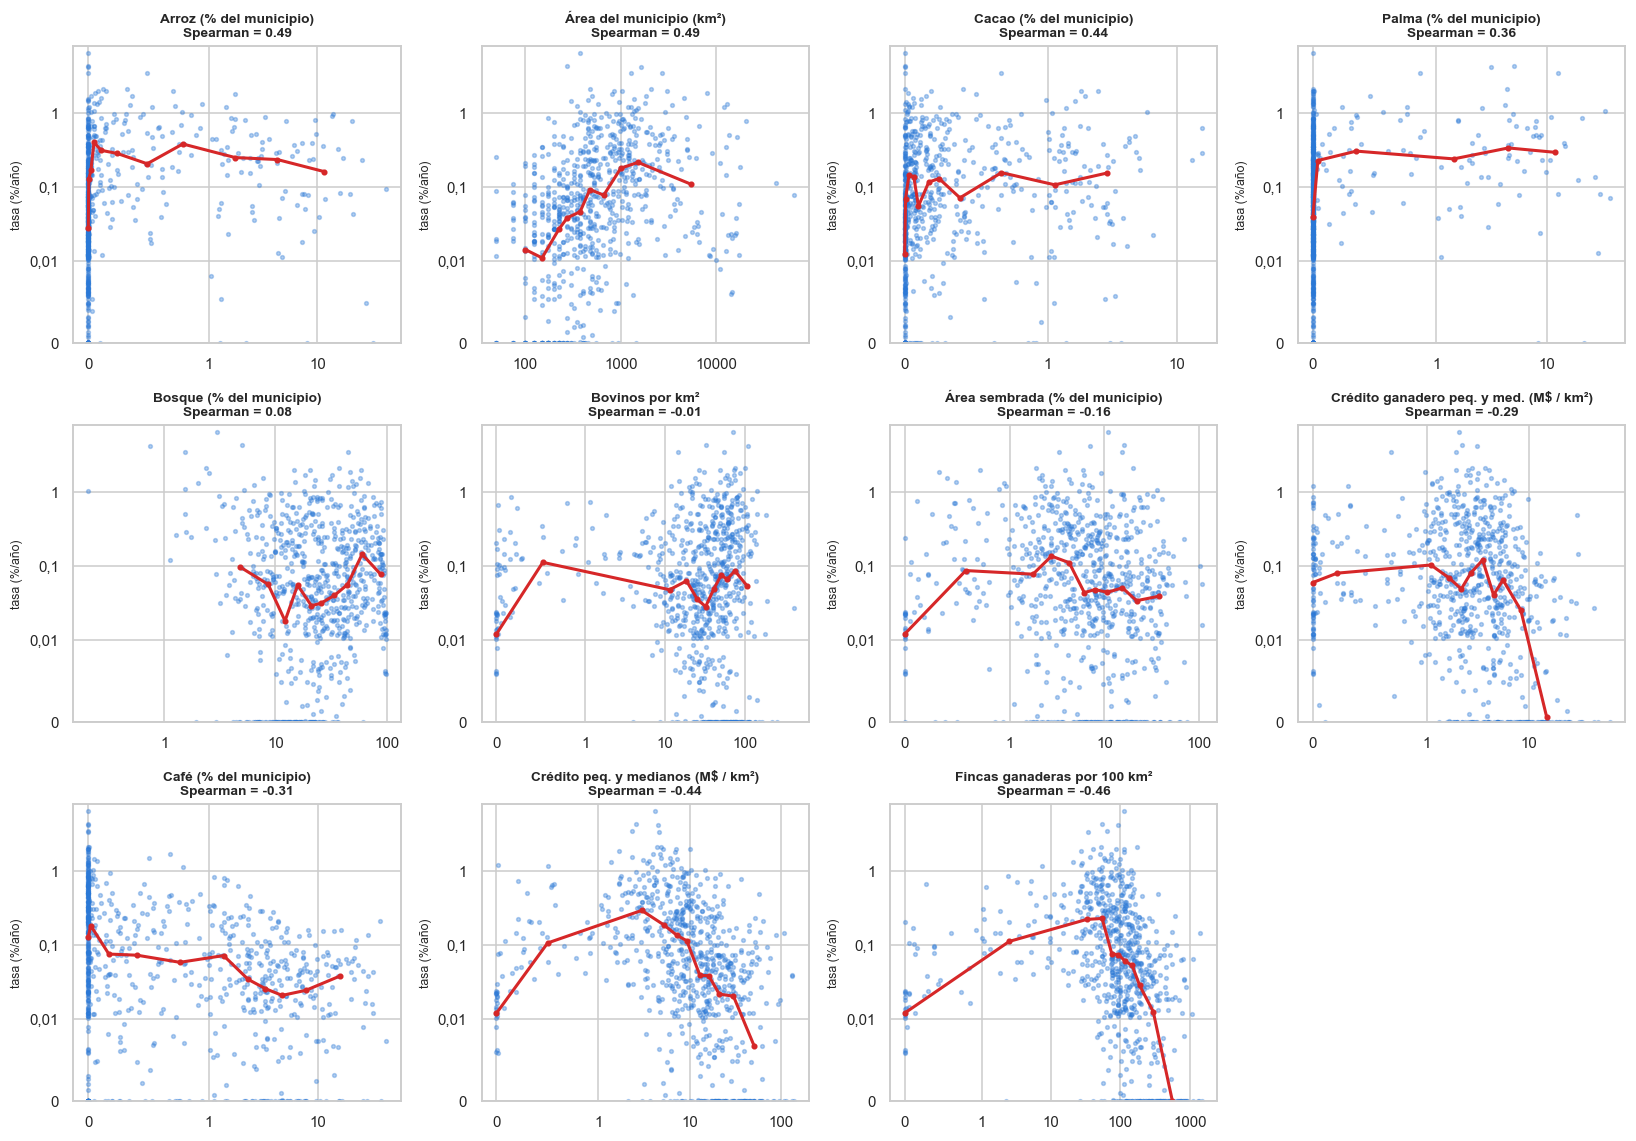

,municipios con el cultivo,tasa típica sin el cultivo (%/año),tasa típica con el cultivo (%/año)
Arroz (% del municipio),257,0.027,0.229
Cacao (% del municipio),493,0.012,0.111
Palma (% del municipio),118,0.039,0.271
Café (% del municipio),513,0.129,0.044


In [14]:
ORDEN_DISPERSION = correlaciones.index[::-1]   # de la mas positiva a la mas negativa
fig, axes = plt.subplots(3, 4, figsize=(15, 10.5))
for ax, c in zip(axes.flat, ORDEN_DISPERSION):
    p = municipios[[c, "tasa"]].dropna()
    ax.scatter(p[c], p.tasa, s=6, alpha=.35, color="#2a78d6")
    # Los municipios en cero forman un punto aparte; los demas se parten en deciles (quintiles si son pocos)
    cero = p[c] == 0
    p["tramo"] = -1
    p.loc[~cero, "tramo"] = pd.qcut(p.loc[~cero, c].rank(method="first"), 10 if (~cero).sum() >= 200 else 5,
                                    labels=False)
    tendencia = p.groupby("tramo")[[c, "tasa"]].median()
    ax.plot(tendencia[c], tendencia.tasa, color="#d62728", lw=2, marker="o", ms=3)
    ax.set_xscale("symlog", linthresh=1 if c != "area" else 10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    eje_tasa(ax)
    ax.set_title(f"{NOMBRES[c]}\nSpearman = {correlaciones.Spearman[c]:.2f}", fontsize=9)
    ax.set_ylabel("tasa (%/año)", fontsize=8)
for ax in axes.flat[len(ORDEN_DISPERSION):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

# En los cultivos, la diferencia principal es tener o no tener el cultivo
(pd.DataFrame({cultivo: {"municipios con el cultivo": (municipios[cultivo] > 0).sum(),
                        "tasa típica sin el cultivo (%/año)": municipios.tasa[municipios[cultivo] == 0].median(),
                        "tasa típica con el cultivo (%/año)": municipios.tasa[municipios[cultivo] > 0].median()}
              for cultivo in ["arroz", "cacao", "palma", "cafe"]}).T.rename(index=NOMBRES).round(3)
 .astype({"municipios con el cultivo": int}))

<!-- lectura:7disp -->
**Qué muestra.**

- **Las nubes son anchas.** Aun con 0,49 (arroz, área) hay municipios con tasas altas y bajas en casi todo el rango.
  Una correlación moderada dice que la tendencia existe, no que cada municipio la siga.
- **En los cultivos, lo que importa es tener o no tener el cultivo.** El municipio típico sin arroz pierde el 0,027 %
  de su bosque al año, y el típico con arroz, el 0,23 %: ocho veces más. Con el cacao, 0,012 % frente a 0,11 %; con la
  palma, 0,039 % frente a 0,27 %. Después del salto, la línea roja queda casi plana: tener más arroz, cacao o palma no
  va con más deforestación. El café va al revés: 0,13 % sin café y 0,044 % con café.
- **Área:** la tasa sube de forma pareja con el tamaño hasta unos 2 000 km² y baja un poco en los más grandes.
- **Crédito y fincas:** la línea sube al principio y cae fuerte en los municipios con más crédito o más fincas. Es la
  U invertida que se ve en detalle en la sección 8.
- **Bovinos y bosque:** la nube no tiene dirección, y la línea sube y baja sin patrón.

### 7.3 Todas las variables entre sí

**La pregunta.** ¿Qué variables van juntas? Si dos variables explicativas están muy correlacionadas entre sí, es
difícil saber cuál de las dos es la que se relaciona con la deforestación.

**Cómo se hace.** La matriz de correlaciones de Spearman entre todas las variables. Solo se muestra la mitad de abajo,
porque la de arriba es igual (la correlación de A con B es la misma que la de B con A). Las variables van agrupadas:
deforestación, crédito, ganado, cultivos y territorio.

**Cómo leer el gráfico.** Rojo es positiva y azul, negativa; mientras más intenso el color, más fuerte. Las líneas
negras separan los grupos de variables.

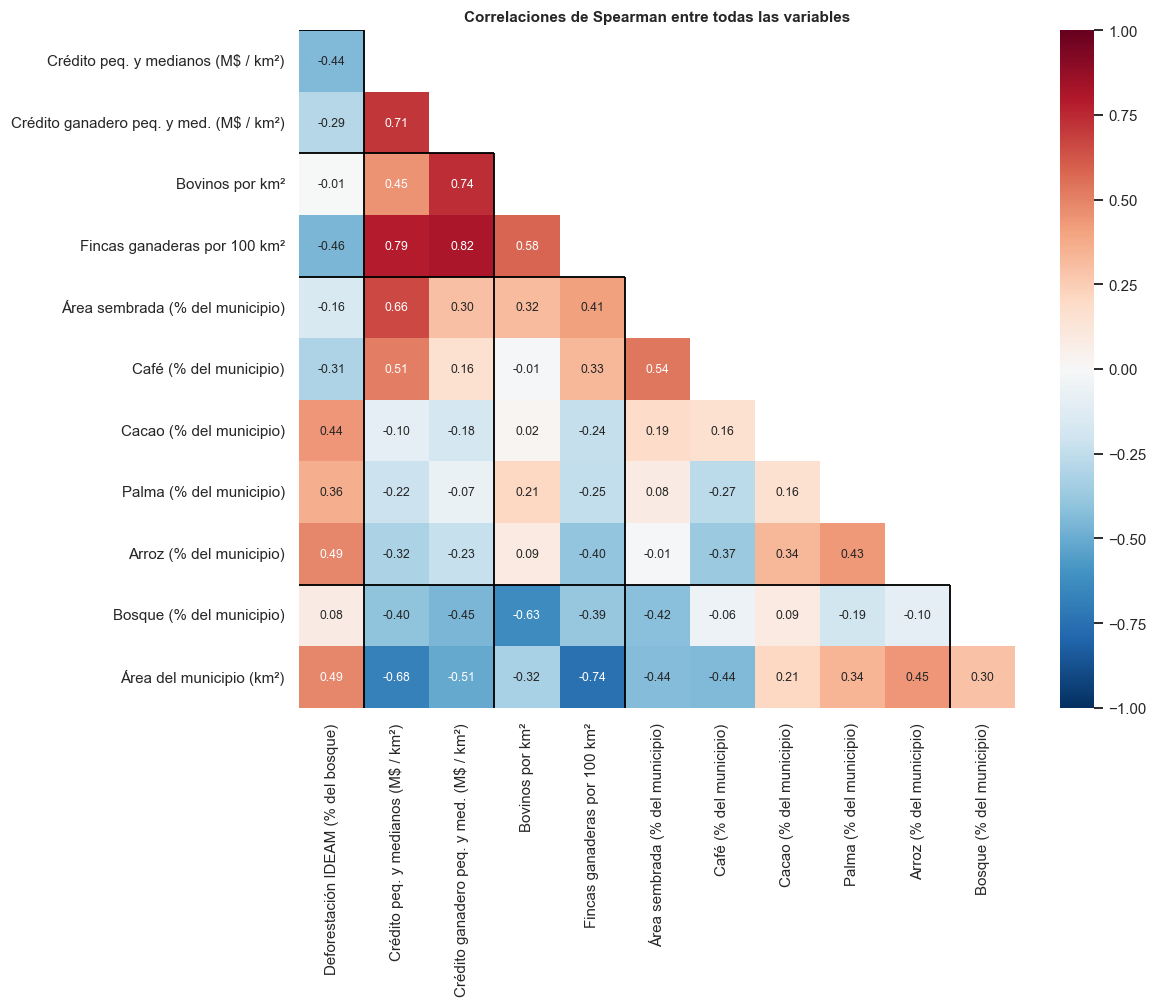

Pares de variables: 66
Cuántos hay de cada tamaño: {'fuerte': 12, 'moderada': 25, 'débil': 19, 'nada': 10}
Pares cuyo intervalo cruza el cero: 5

Los 12 pares más fuertes:


,variable A,variable B,Spearman,desde,hasta,tamaño
0,Fincas ganaderas por 100 km²,Crédito ganadero peq. y med. (M$ / km²),0.82,0.78,0.85,fuerte
1,Fincas ganaderas por 100 km²,Crédito peq. y medianos (M$ / km²),0.79,0.75,0.82,fuerte
2,Área del municipio (km²),Fincas ganaderas por 100 km²,-0.74,-0.77,-0.71,fuerte
3,Bovinos por km²,Crédito ganadero peq. y med. (M$ / km²),0.74,0.70,0.78,fuerte
4,Crédito ganadero peq. y med. (M$ / km²),Crédito peq. y medianos (M$ / km²),0.71,0.67,0.75,fuerte
5,Área del municipio (km²),Crédito peq. y medianos (M$ / km²),-0.68,-0.71,-0.63,fuerte
6,Área sembrada (% del municipio),Crédito peq. y medianos (M$ / km²),0.66,0.62,0.71,fuerte
7,Bosque (% del municipio),Bovinos por km²,-0.63,-0.68,-0.58,fuerte
8,Fincas ganaderas por 100 km²,Bovinos por km²,0.58,0.52,0.63,fuerte
9,Café (% del municipio),Área sembrada (% del municipio),0.54,0.47,0.59,fuerte


In [15]:
ORDEN_MATRIZ = ["tasa", "cred_pm", "cred_gan", "bovinos", "fincas", "agricola", "cafe", "cacao", "palma", "arroz",
                "bosque", "area"]
CORTES = [1, 3, 5, 10]   # despues de: deforestacion | credito | ganado | cultivos | territorio
matriz = municipios[ORDEN_MATRIZ].corr(method="spearman")
# Sin la primera fila ni la ultima columna, que en la mitad de abajo quedarian vacias
mitad = matriz.iloc[1:, :-1]
fig, ax = plt.subplots(figsize=(10.5, 8))
sns.heatmap(mitad.rename(index=NOMBRES, columns=NOMBRES), mask=np.triu(np.ones_like(mitad, bool), k=1),
            annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, annot_kws={"size": 8}, ax=ax)
ax.grid(False)
for corte in CORTES:
    ax.hlines(corte - 1, 0, corte, color="black", lw=1.2)
    ax.vlines(corte, corte - 1, len(mitad), color="black", lw=1.2)
ax.set_title("Correlaciones de Spearman entre todas las variables")
plt.show()

# Bootstrap de la matriz completa, para saber que pares no se distinguen de cero
rng = np.random.default_rng(1)
replicas_matriz = np.array([municipios[ORDEN_MATRIZ].iloc[rng.integers(0, len(municipios), len(municipios))]
                            .corr(method="spearman").values for _ in range(500)])
desde, hasta = np.percentile(replicas_matriz, 2.5, 0), np.percentile(replicas_matriz, 97.5, 0)
i, j = np.tril_indices(len(ORDEN_MATRIZ), -1)
pares = pd.DataFrame({"variable A": [NOMBRES[ORDEN_MATRIZ[k]] for k in i],
                      "variable B": [NOMBRES[ORDEN_MATRIZ[k]] for k in j],
                      "Spearman": matriz.values[i, j], "desde": desde[i, j], "hasta": hasta[i, j]})
pares["tamaño"] = pd.cut(pares.Spearman.abs(), [0, .1, .3, .5, 1], labels=["nada", "débil", "moderada", "fuerte"],
                         include_lowest=True)
print(f"Pares de variables: {len(pares)}")
print("Cuántos hay de cada tamaño:", pares["tamaño"].value_counts().reindex(["fuerte", "moderada", "débil", "nada"]).to_dict())
print(f"Pares cuyo intervalo cruza el cero: {((pares.desde < 0) & (pares.hasta > 0)).sum()}")
print("\nLos 12 pares más fuertes:")
pares.reindex(pares.Spearman.abs().sort_values(ascending=False).index).head(12).round(2).reset_index(drop=True)

<!-- lectura:7b -->
**Qué muestra.**

- De los 66 pares de variables, 12 tienen una correlación fuerte, 25 moderada, 19 débil y 10 nada. Solo 5 pares
  tienen un intervalo que cruza el cero: con 777 municipios, casi cualquier relación se distingue del azar, así que lo
  que importa es su tamaño.
- **El bloque más fuerte es crédito y ganado.** Las fincas van con el crédito ganadero (0,82) y con el crédito
  (0,79); los bovinos, con el crédito ganadero (0,74). Donde hay ganado hay fincas y hay crédito. Van tan juntos que,
  con correlaciones, no se puede saber cuál de ellos es el que se relaciona con la deforestación. El PCA de la sección
  9 los trata como una sola dirección.
- **El territorio va en contra de casi todo.** Los municipios grandes tienen menos crédito (−0,68) y menos fincas
  (−0,74) por km². El bosque va en contra de los bovinos (−0,63): donde hay potreros ya no hay bosque.
- **Los cultivos forman dos familias.** El café va con el área sembrada (0,54) y el crédito (0,51): es el municipio
  andino. El arroz va con la palma (0,43), el cacao (0,34) y el área del municipio (0,45): son municipios grandes y de
  tierras bajas. El arroz y el café van en contra (−0,37).
- **La primera columna se explica con esas familias.** Lo que va con más deforestación (arroz, cacao, palma, área)
  es la familia de los municipios grandes y de tierras bajas. Lo que va con menos (crédito, fincas, café) es la
  familia andina.

### 7.4 ¿Cambia el resultado según cómo se mida la deforestación?

**La pregunta.** Hasta aquí la deforestación se midió como **tasa**: qué parte de su bosque pierde el municipio.
También se puede medir como **hectáreas deforestadas por cada 100 km² de municipio**, con el IDEAM o con las alertas
de GFW. ¿Dan las mismas correlaciones?

**Por qué importa.** Las dos medidas responden preguntas diferentes:

- La **tasa** compara lo que se pierde con el bosque que hay. Un municipio con poco bosque que pierde la mitad tiene
  una tasa alta.
- Las **hectáreas por km²** miden cuánto se tumba por unidad de territorio. Un municipio con mucho bosque puede tener
  muchas hectáreas aunque pierda una parte pequeña. Esta medida depende de cuánto bosque queda.

**Cómo leer el mapa de calor.** Cada columna es una forma de medir la deforestación; cada fila, una variable.

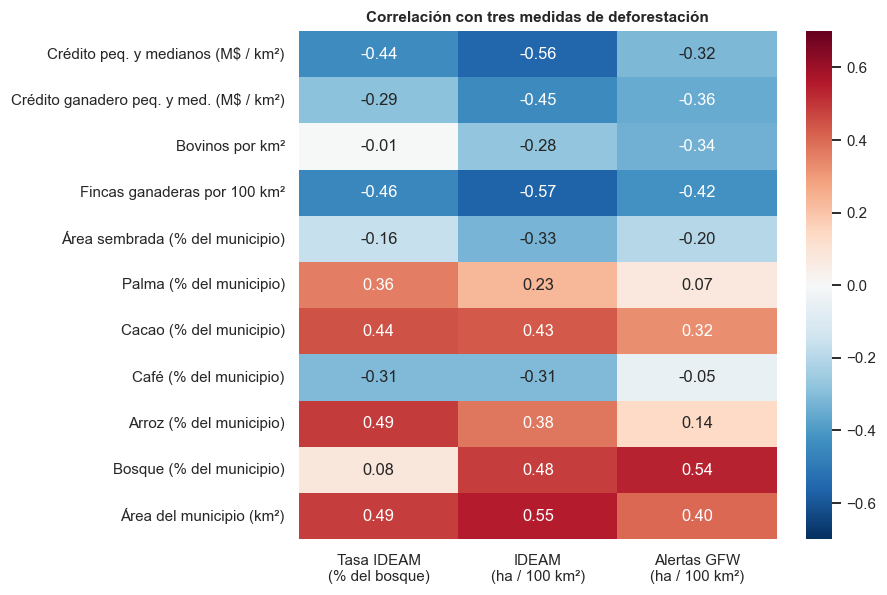

In [16]:
MEDIDAS = {"tasa": "Tasa IDEAM\n(% del bosque)", "def_100km2": "IDEAM\n(ha / 100 km²)",
           "gfw_100km2": "Alertas GFW\n(ha / 100 km²)"}
por_medida = municipios[list(MEDIDAS) + VARIABLES].corr(method="spearman").loc[VARIABLES, list(MEDIDAS)]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(por_medida.rename(index=NOMBRES, columns=MEDIDAS), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-.7,
            vmax=.7, ax=ax)
ax.set(title="Correlación con tres medidas de deforestación", xlabel="", ylabel="")
plt.show()

<!-- lectura:7medidas -->
**Qué muestra.**

- **Las tres medidas coinciden en lo básico:** el crédito y las fincas salen negativos, y el cacao y el área del
  municipio, positivos.
- **Con hectáreas por km², el bosque pasa de 0,08 a 0,48 (IDEAM) y 0,54 (GFW).** Esa medida depende sobre todo de
  cuánto bosque hay: donde hay más bosque, hay más hectáreas que tumbar.
- **Por lo mismo, los bovinos pasan de cero a negativos** (−0,28 con el IDEAM y −0,34 con GFW). Los municipios con
  más ganado tienen menos bosque (−0,63, sección 7.3), así que tienen menos hectáreas para perder.
- Con GFW, el arroz y la palma casi desaparecen (0,14 y 0,07), y el café también (−0,05).
- **Por qué la tasa es la medida principal.** La tasa compara lo que se pierde con el bosque que hay, así que mide
  la presión sobre el bosque. Las hectáreas por km² mezclan esa presión con la pregunta de dónde queda bosque. Si se
  reporta una correlación con la deforestación, conviene decir con qué medida se calculó.

### 7.5 ¿Cambian las correlaciones de un año a otro?

**La pregunta.** Las correlaciones anteriores usan el promedio de los cinco años. ¿Darían lo mismo con cada año por
separado?

**Cómo se hace.** Se calcula la correlación con la tasa de deforestación dentro de cada año, de 2021 a 2025, usando
la tabla municipio-año (las variables explicativas, como siempre, del año anterior). La última columna es la que se
usó hasta aquí, con el promedio de los cinco años.

**Cómo leer el mapa de calor.** Si cada fila tiene colores parecidos, la correlación es estable en el tiempo.

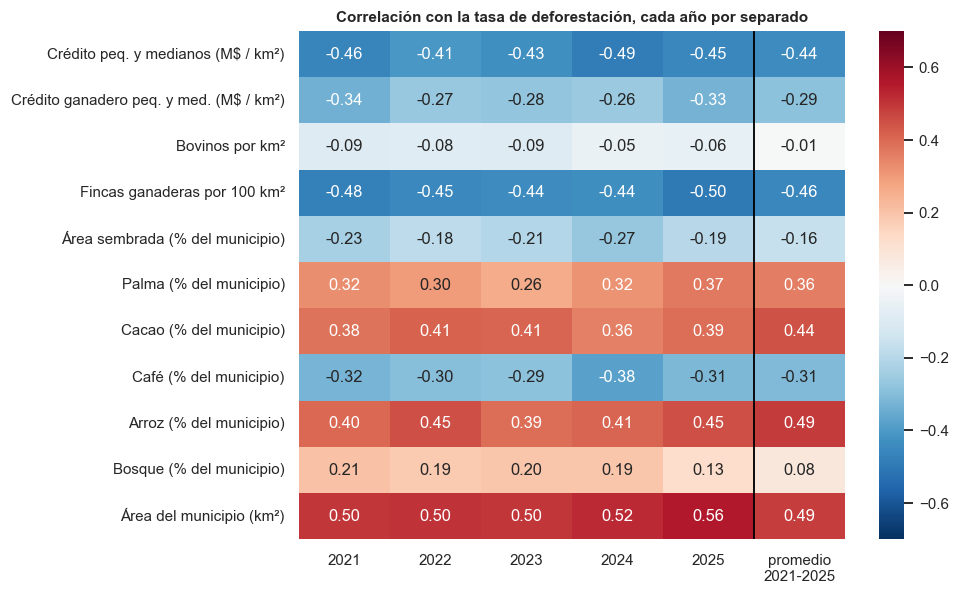

,% de años sin deforestación
municipios con,
poco bosque,68.0
bosque medio,31.0
mucho bosque,4.0


In [17]:
por_anio = muestra.groupby("anio").apply(lambda t: t[columnas].corr(method="spearman")["tasa"][VARIABLES]).T
por_anio["promedio\n2021-2025"] = correlaciones.Spearman
por_anio.columns = [str(c) for c in por_anio.columns]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(por_anio.rename(index=NOMBRES), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-.7, vmax=.7, ax=ax)
ax.axvline(5, color="black", lw=1.2)
ax.set(title="Correlación con la tasa de deforestación, cada año por separado", xlabel="", ylabel="")
plt.show()
# Cuantos municipio-anio tienen tasa cero, segun cuanto bosque tienen
tercil = pd.qcut(muestra.bosque_ideam_inicial_ha, 3, labels=["poco bosque", "bosque medio", "mucho bosque"])
((100 * (muestra.tasa == 0).groupby(tercil, observed=True).mean()).round(0).rename_axis("municipios con")
 .rename("% de años sin deforestación").to_frame())

<!-- lectura:7anios -->
**Qué muestra.**

- **Las correlaciones son estables.** Cada año da casi lo mismo que el promedio, con diferencias de 0,1 o poco más. El
  crédito da entre −0,41 y −0,49; las fincas, entre −0,44 y −0,50; el arroz, entre 0,39 y 0,45; el área, entre 0,50 y
  0,56.
- **Dos diferencias pequeñas.** Los bovinos dan entre −0,05 y −0,09 cada año y −0,01 con el promedio: en los dos
  casos, casi nada. El bosque da entre 0,13 y 0,21 cada año y 0,08 con el promedio. La tabla explica por qué: en un
  solo año, el 68 % de los municipios con poco bosque no pierde nada y quedan todos empatados en cero, al fondo del
  orden. Con el promedio de cinco años hay menos ceros.
- **Usar el promedio de los cinco años no esconde nada:** da las mismas conclusiones que cada año por separado.

### 7.6 ¿Por qué Spearman y no Pearson?

**La pregunta.** La correlación más conocida es la de Pearson. ¿Por qué aquí se usa Spearman?

**Cómo se hace.** Se calculan las dos para cada variable frente a la tasa de deforestación. Pearson usa los valores;
Spearman, el orden de los municipios. También se calcula Pearson quitando los 8 municipios más extremos de cada
variable, para ver cuánto pesan unos pocos casos.

In [18]:
def pearson_sin_extremos(c, n=8):
    x, y = municipios[c], municipios.tasa
    quedan = (y.rank(ascending=False) > n) & (x.rank(ascending=False) > n)
    return x[quedan].corr(y[quedan])


pd.DataFrame({"Spearman": correlaciones.Spearman,
              "Pearson": municipios[VARIABLES].corrwith(municipios.tasa),
              "Pearson sin los 8 más extremos": [pearson_sin_extremos(c) for c in correlaciones.index]},
             index=correlaciones.index).rename(index=NOMBRES).round(2)

,Spearman,Pearson,Pearson sin los 8 más extremos
Fincas ganaderas por 100 km²,-0.46,-0.19,-0.26
Crédito peq. y medianos (M$ / km²),-0.44,-0.21,-0.27
Café (% del municipio),-0.31,-0.17,-0.23
Crédito ganadero peq. y med. (M$ / km²),-0.29,-0.13,-0.17
Área sembrada (% del municipio),-0.16,-0.09,-0.14
Bovinos por km²,-0.01,0.08,0.10
Bosque (% del municipio),0.08,-0.06,-0.01
Palma (% del municipio),0.36,0.13,0.16
Cacao (% del municipio),0.44,0.06,0.12
Área del municipio (km²),0.49,0.05,0.14


<!-- lectura:7pearson -->
**Qué muestra.**

- **Pearson da valores mucho más pequeños:** 0,05 para el área (Spearman: 0,49), 0,03 para el arroz (0,49) y 0,06
  para el cacao (0,44).
- **La razón son unos pocos municipios extremos.** El Guamo, Zambrano, Pivijay y Sabanas de San Ángel, en el
  Caribe, pierden entre 3,5 % y 6,4 % de su bosque al año, entre 60 y 120 veces lo del municipio típico, y no siembran
  arroz. Cumaribo tiene 65 000 km², 150 veces el municipio típico. Pearson usa los valores, así que estos pocos casos
  pesan muchísimo: quitando unos 16 municipios de 777 (los 8 más extremos de cada variable), la correlación de
  Pearson del área pasa de 0,05 a 0,14.
- **Spearman usa el orden.** Para Spearman, El Guamo es "el municipio con la tasa más alta" y nada más; pesa lo mismo
  que cualquier otro. Con datos tan desiguales como estos, es la correlación adecuada.
- Las dos coinciden en el signo en todas las variables, salvo los bovinos y el bosque, que con las dos dan casi cero.

### 7.7 Las correlaciones dentro de cada región

**La pregunta.** El país no es homogéneo. ¿Las correlaciones con la deforestación son las mismas en todas las
regiones?

**Cómo se hace.** La correlación de Spearman con la tasa de deforestación, calculada solo entre los municipios de
cada región.

**Cómo leer el mapa de calor.** Cada columna es una región. Como cada región tiene menos municipios, una correlación
pequeña puede salir por azar: la tabla de abajo dice, para cada región, a partir de qué valor tomarla en serio.

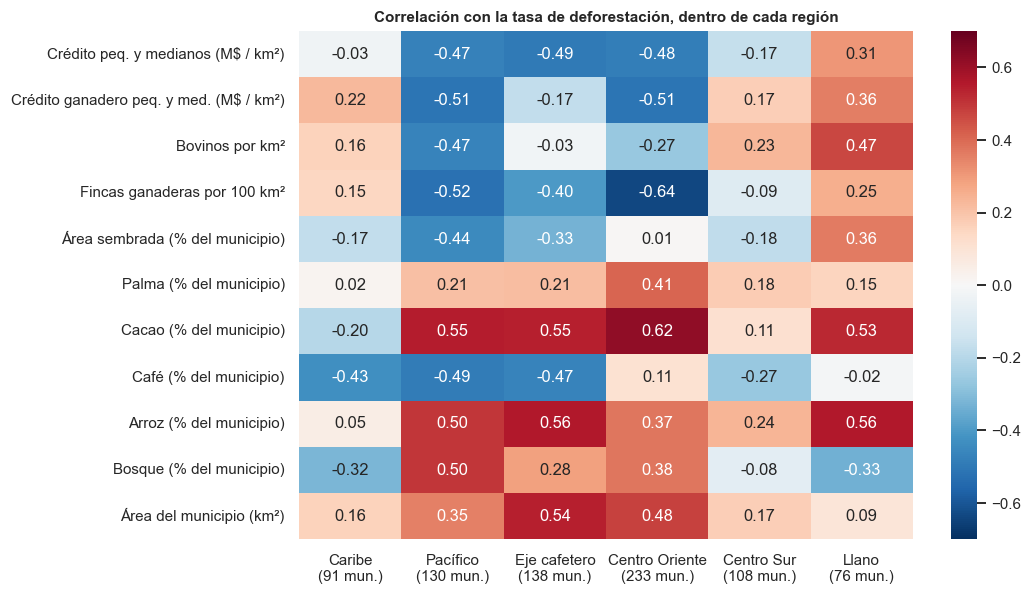

,a partir de qué valor la correlación cuenta
region,
Caribe,0.21
Pacífico,0.18
Eje cafetero,0.17
Centro Oriente,0.13
Centro Sur,0.19
Llano,0.23


In [19]:
regiones = municipios.groupby("region")
por_region = regiones.apply(lambda g: g[columnas].corr(method="spearman")["tasa"][VARIABLES]).T
tamanos = regiones.size()
por_region.columns = [f"{r}\n({n} mun.)" for r, n in tamanos.items()]
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(por_region.rename(index=NOMBRES), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-.7, vmax=.7, ax=ax)
ax.set(title="Correlación con la tasa de deforestación, dentro de cada región", xlabel="", ylabel="")
plt.show()
# Regla para leer el mapa de calor: con n municipios, una correlacion menor a 2 / raiz(n)
# en valor absoluto no se distingue de cero
(2 / np.sqrt(tamanos)).round(2).rename("a partir de qué valor la correlación cuenta").to_frame()

<!-- lectura:7c -->
**Qué muestra.** Recordando la regla: en el Llano (76 municipios) hay que pasar de 0,23 para tomar en serio una
correlación; en Centro Oriente (233), de 0,13.

- **El Llano es la excepción.** Allí el ganado y el crédito sí van con más deforestación: bovinos 0,47, crédito
  ganadero 0,36, crédito 0,31, área sembrada 0,36.
- En el Pacífico, el Eje cafetero y Centro Oriente pasa lo contrario: más crédito y más fincas, menos deforestación
  (entre −0,40 y −0,64).
- El cacao y el arroz van con más deforestación en casi todas las regiones. El cacao, entre 0,53 y 0,62 en el
  Pacífico, el Eje cafetero, Centro Oriente y el Llano.
- En el Caribe y Centro Sur las relaciones son más débiles. En Centro Sur los bovinos van con algo más de
  deforestación (0,23); en el Caribe el café va con menos (−0,43).
- El cero de los bovinos en el país entero esconde relaciones que, dentro de cada región, van en sentidos opuestos.

### 7.8 La matriz completa en cada región

**La pregunta.** La sección 7.7 solo mira la correlación con la deforestación. ¿Las demás variables también se
relacionan igual entre sí en todas las regiones? Por ejemplo, ¿el crédito va con las fincas en todas partes?

**Cómo se hace.** La misma matriz de la sección 7.3, calculada solo con los municipios de cada región. Hay una matriz
por región, ordenadas de la que más deforesta a la que menos.

**Cómo leer las matrices.** Igual que la de la sección 7.3. La diferencia es que cada región tiene pocos municipios,
así que una correlación pequeña puede salir por azar. Las celdas con color pasan el umbral de su región (2/√*n*,
indicado en el título). Las celdas en blanco, con el número en gris, no lo pasan: no se distinguen del azar.

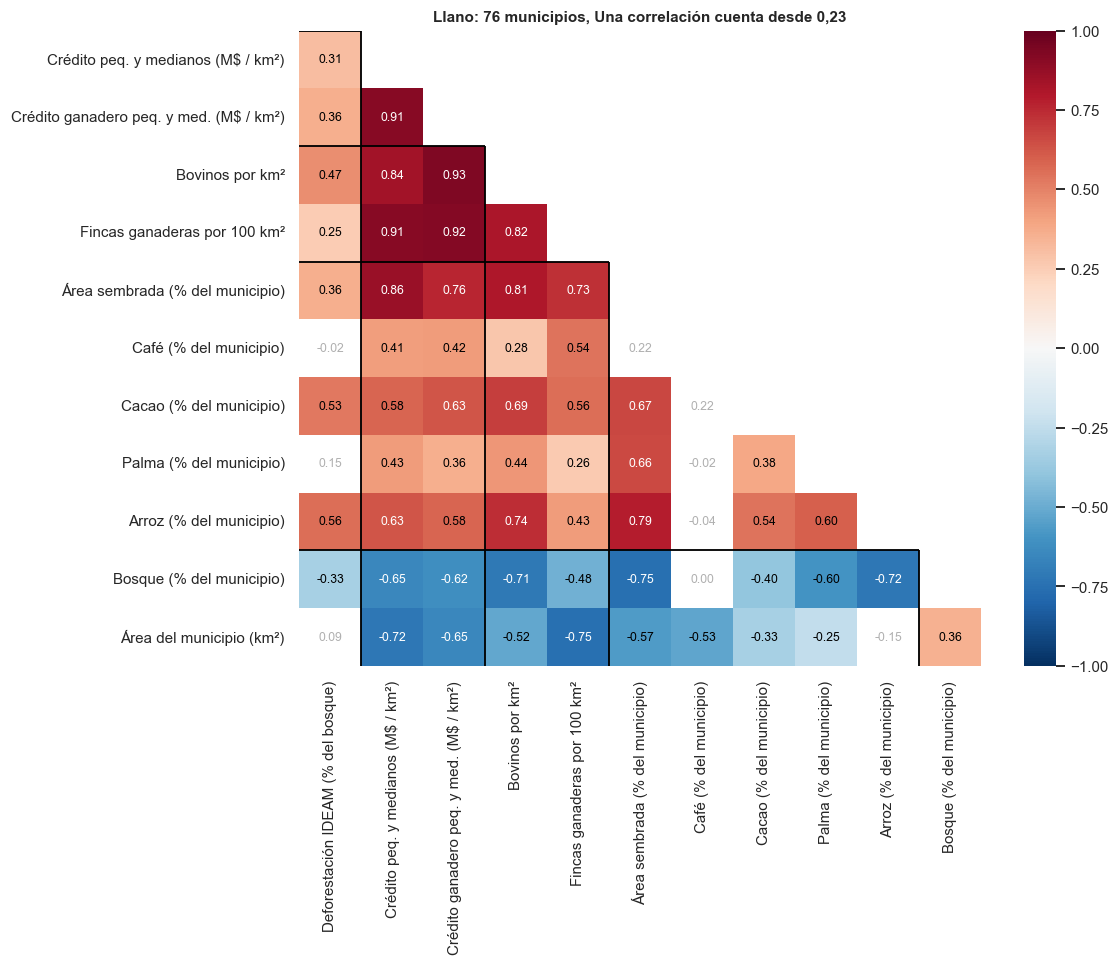

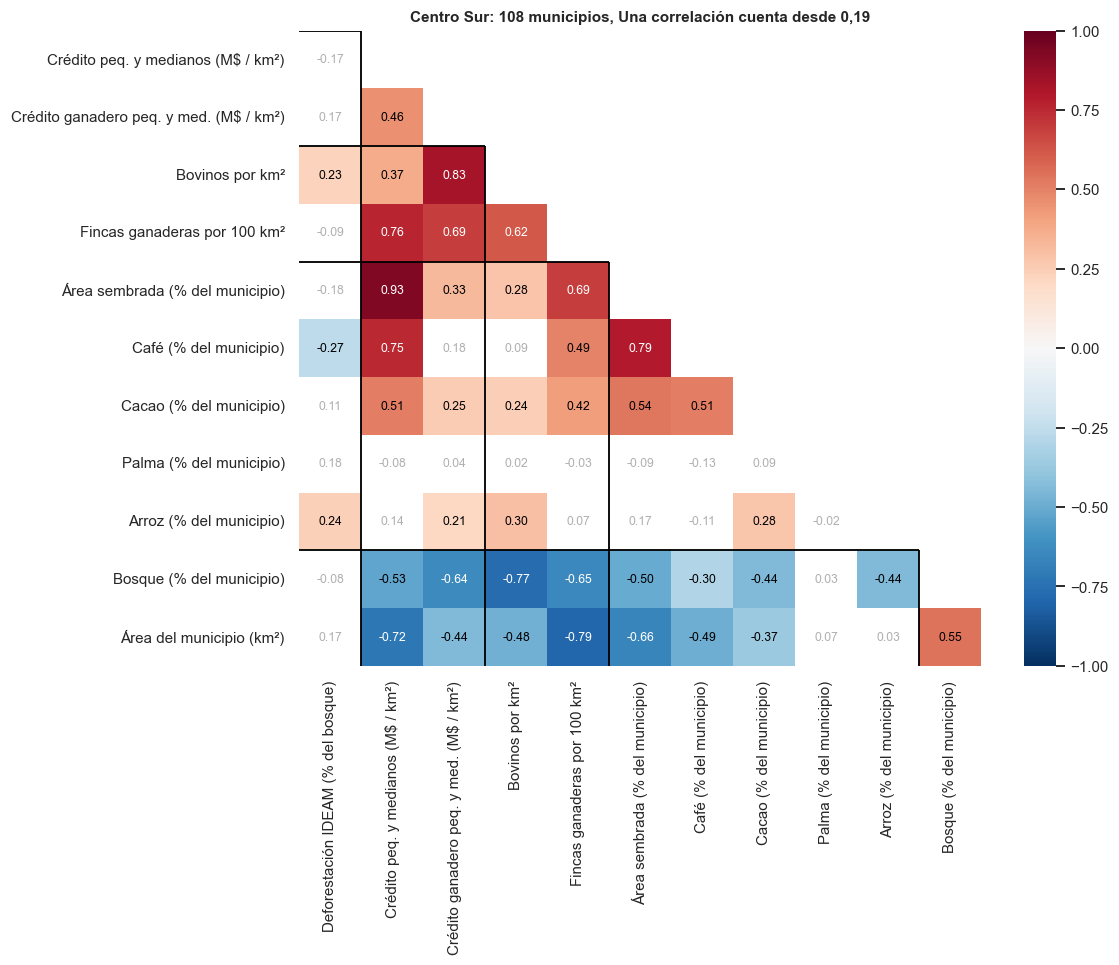

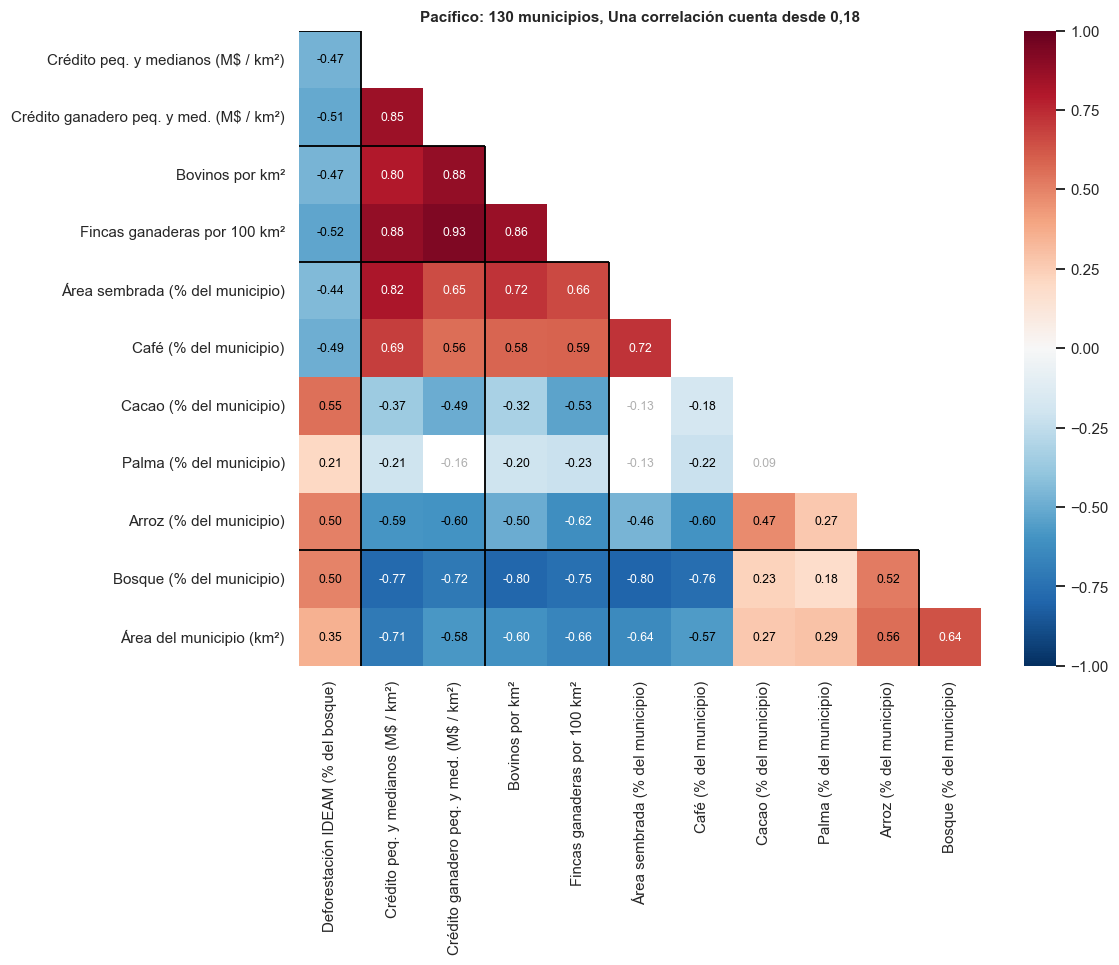

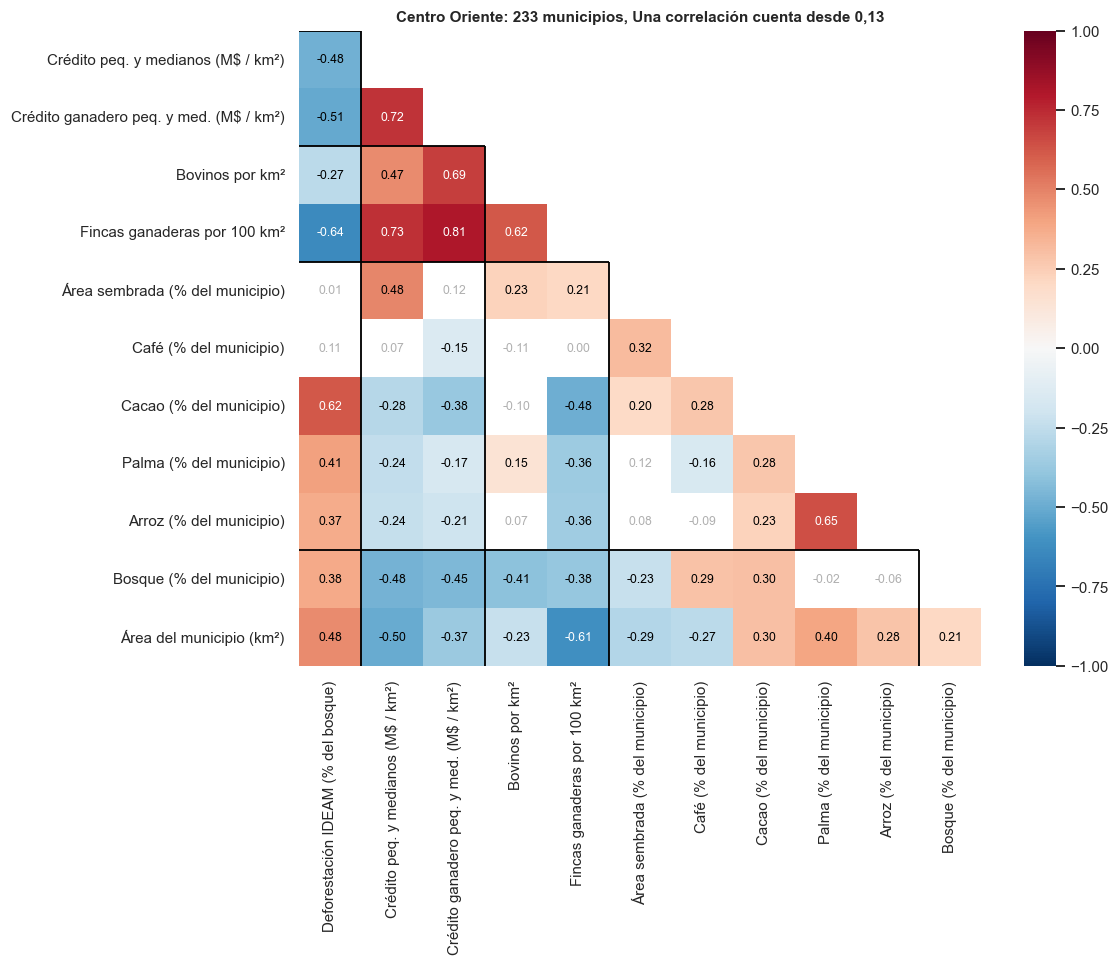

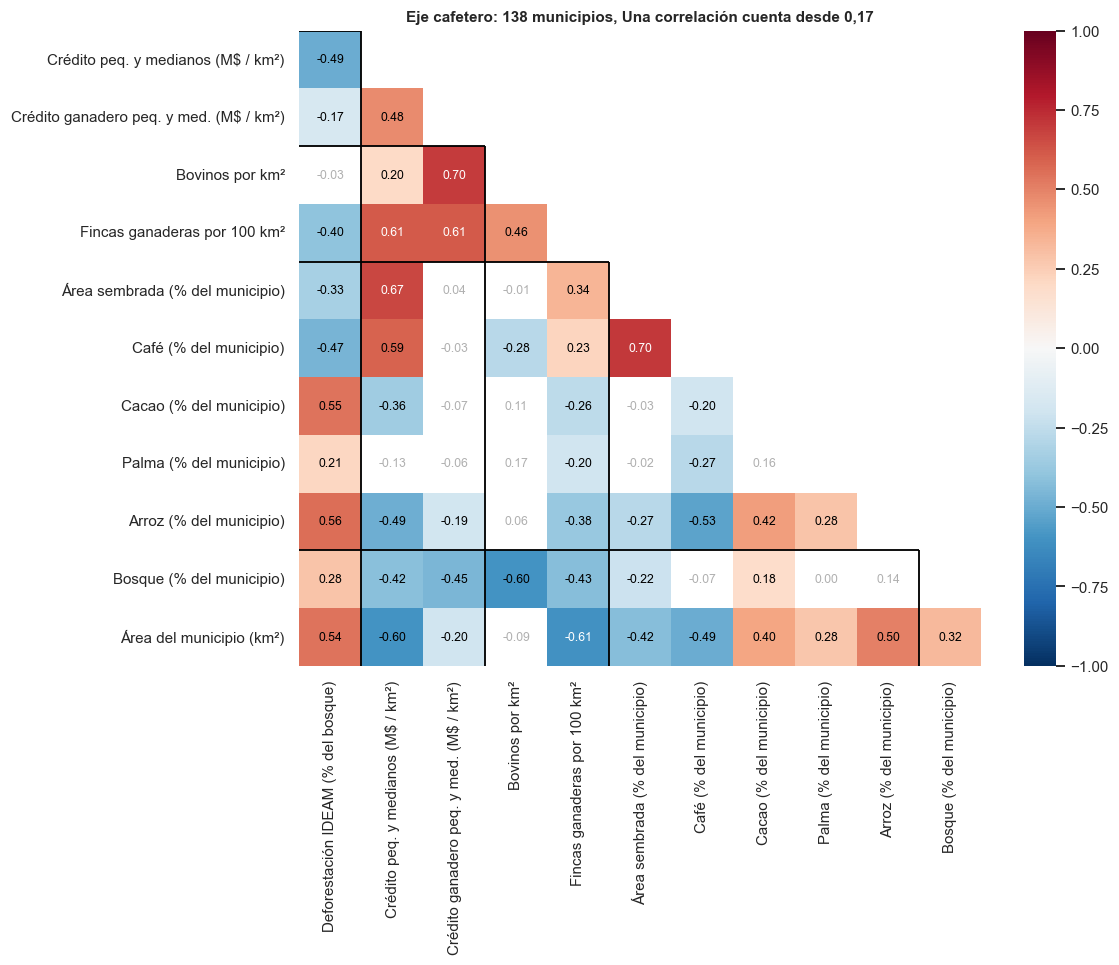

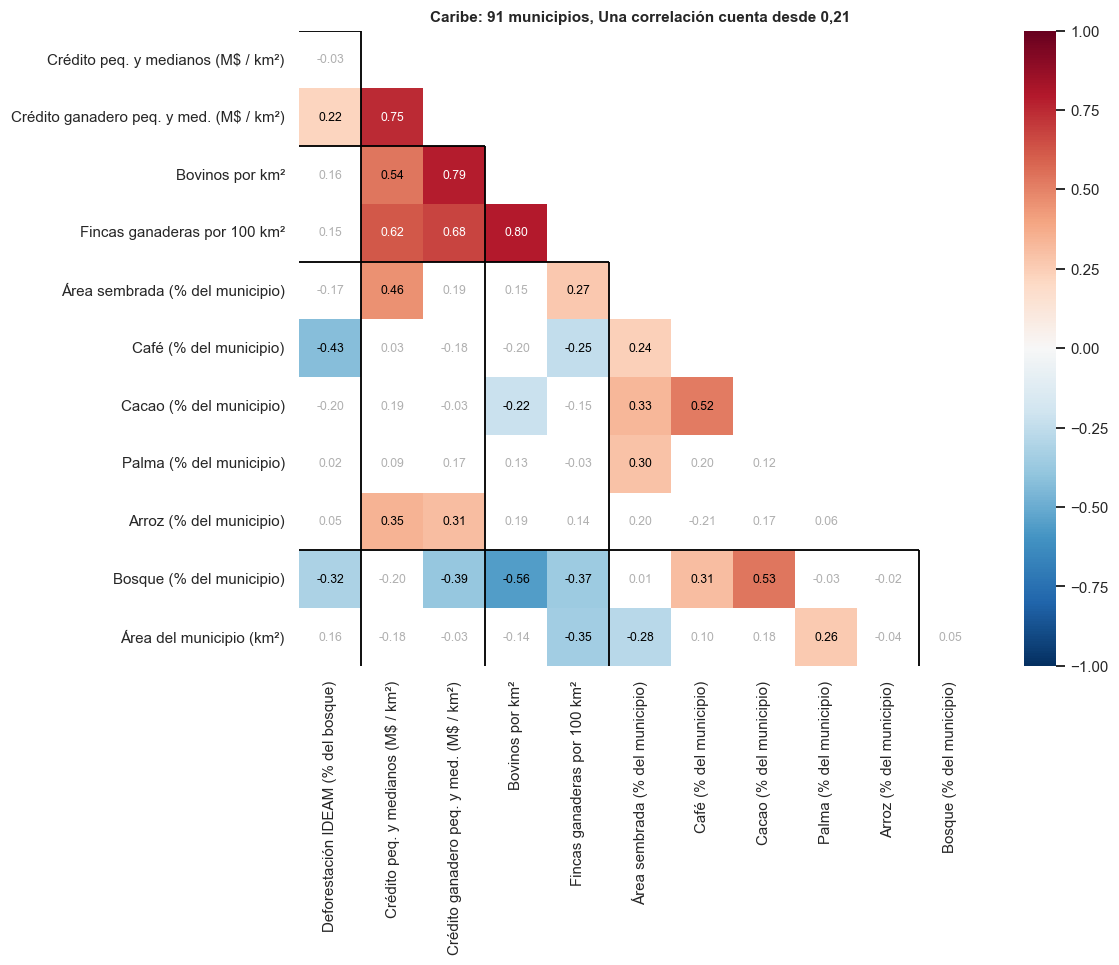

In [20]:
ORDEN_REGIONES = municipios.groupby("region").def_total_ha.sum().sort_values(ascending=False).index
matrices_region = {}
for region in ORDEN_REGIONES:
    sub = municipios[municipios.region == region]
    umbral = 2 / np.sqrt(len(sub))
    m = sub[ORDEN_MATRIZ].corr(method="spearman")
    matrices_region[region] = m
    mitad = m.iloc[1:, :-1]
    abajo = np.tril(np.ones_like(mitad, bool))
    cuenta = abajo & (mitad.abs().values >= umbral)

    fig, ax = plt.subplots(figsize=(10, 7.5))
    sns.heatmap(mitad.where(cuenta).rename(index=NOMBRES, columns=NOMBRES), cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
    for (r, c), v in np.ndenumerate(mitad.values):
        if abajo[r, c]:
            color = ("white" if abs(v) > .6 else "black") if cuenta[r, c] else "#b0b0b0"
            ax.text(c + .5, r + .5, f"{v:.2f}", ha="center", va="center", fontsize=8, color=color)
    ax.grid(False)
    for corte in CORTES:
        ax.hlines(corte - 1, 0, corte, color="black", lw=1.2)
        ax.vlines(corte, corte - 1, len(mitad), color="black", lw=1.2)
    ax.set_title(f"{region}: {len(sub)} municipios. Una correlación cuenta desde {umbral:.2f}".replace(".", ","))
    plt.show()

<!-- lectura:7regiones -->
**Qué muestra.**

- **En todas las regiones, el crédito y el ganado van juntos y van en contra del bosque.** El bloque de crédito,
  bovinos y fincas sale en rojo en las seis matrices, y la fila del bosque sale en azul debajo de ese bloque. Es el
  patrón más firme del notebook.
- **Llano** (Meta, Casanare, Arauca, Guaviare, Vichada, Guainía y Vaupés). Toda la actividad agropecuaria va junta:
  crédito, ganado, área sembrada, arroz, cacao y palma se correlacionan entre sí casi siempre por encima de 0,4, y
  hasta 0,93. Es la única región donde casi todo va con más deforestación: bovinos 0,47, arroz 0,56, cacao 0,53,
  crédito ganadero 0,36.
- **Centro Sur** (Tolima, Huila, Caquetá, Putumayo y Amazonas). La deforestación casi no se relaciona con nada: solo
  los bovinos (0,23), el arroz (0,24) y el café (−0,27) pasan el umbral. La región junta municipios andinos (Tolima,
  Huila) con amazónicos (Caquetá, Putumayo, Amazonas), y al mezclarlos las relaciones se diluyen.
- **Pacífico** (Nariño, Chocó, Cauca y Valle). Hay dos mundos. En uno, el crédito, el ganado, el área sembrada y el
  café van juntos (0,56 a 0,93), con poco bosque y poca deforestación (entre −0,44 y −0,52). En el otro, el arroz y el
  cacao van con el bosque y con la deforestación (arroz 0,50, cacao 0,55). Se deforesta en los municipios boscosos con
  arroz y cacao, y no donde hay ganado y crédito.
- **Centro Oriente** (Santander, Cundinamarca, Boyacá y Norte de Santander). Más fincas, menos deforestación (−0,64);
  más cacao, más deforestación (0,62). La palma y el arroz van juntos (0,65), y los dos con más deforestación (0,41 y
  0,37).
- **Eje cafetero** (sobre todo Antioquia, con 108 de sus 138 municipios). La deforestación va en contra del crédito
  (−0,49) y del café (−0,47), y a favor del arroz (0,56), el cacao (0,55) y el área del municipio (0,54).
- **Caribe** (Bolívar, Cesar, La Guajira, Magdalena, Córdoba y Sucre). La deforestación casi no se relaciona con
  nada, salvo el café (−0,43), el bosque (−0,32) y, apenas, el crédito ganadero (0,22). Lo del bosque quiere decir
  que los municipios con menos bosque pierden una parte mayor del que tienen.

**¿Qué pares cambian más de una región a otra, y cuáles se mantienen?** Para cada par de variables se calcula la
diferencia entre la región donde la correlación es más alta y la región donde es más baja. Una diferencia grande
quiere decir que la relación depende de la región; una pequeña, que se repite en todo el país.

In [21]:
from IPython.display import display

fila, columna = np.tril_indices(len(ORDEN_MATRIZ), -1)
por_par = pd.DataFrame({region: m.values[fila, columna] for region, m in matrices_region.items()},
                       index=[f"{CORTOS[ORDEN_MATRIZ[a]]} – {CORTOS[ORDEN_MATRIZ[b]]}" for a, b in zip(fila, columna)])
por_par["país"] = matriz.values[fila, columna]
por_par["diferencia entre regiones"] = por_par[list(ORDEN_REGIONES)].max(axis=1) - por_par[list(ORDEN_REGIONES)].min(axis=1)
por_par = por_par.sort_values("diferencia entre regiones", ascending=False)

print("Los 12 pares que más cambian entre regiones:")
display(por_par.head(12).round(2))
print("Los 12 pares que más se repiten en todas las regiones (entre los que no son cero en el país):")
display(por_par[por_par["país"].abs() >= .1].tail(12).iloc[::-1].round(2))

Los 12 pares que más cambian entre regiones:


,Llano,Centro Sur,Pacífico,Centro Oriente,Eje cafetero,Caribe,país,diferencia entre regiones
arroz – área sembrada,0.79,0.17,-0.46,0.08,-0.27,0.20,-0.01,1.25
bosque – arroz,-0.72,-0.44,0.52,-0.06,0.14,-0.02,-0.10,1.24
arroz – bovinos,0.74,0.30,-0.50,0.07,0.06,0.19,0.09,1.23
arroz – crédito,0.63,0.14,-0.59,-0.24,-0.49,0.35,-0.32,1.22
arroz – crédito ganadero,0.58,0.21,-0.60,-0.21,-0.19,0.31,-0.23,1.18
cacao – crédito ganadero,0.63,0.25,-0.49,-0.38,-0.07,-0.03,-0.18,1.12
cacao – fincas,0.56,0.42,-0.53,-0.48,-0.26,-0.15,-0.24,1.09
bosque – café,0.00,-0.30,-0.76,0.29,-0.07,0.31,-0.06,1.07
arroz – fincas,0.43,0.07,-0.62,-0.36,-0.38,0.14,-0.40,1.05
cacao – bovinos,0.69,0.24,-0.32,-0.10,0.11,-0.22,0.02,1.01


Los 12 pares que más se repiten en todas las regiones (entre los que no son cero en el país):


,Llano,Centro Sur,Pacífico,Centro Oriente,Eje cafetero,Caribe,país,diferencia entre regiones
bovinos – crédito ganadero,0.93,0.83,0.88,0.69,0.70,0.79,0.74,0.24
palma – cacao,0.38,0.09,0.09,0.28,0.16,0.12,0.16,0.29
fincas – crédito,0.91,0.76,0.88,0.73,0.61,0.62,0.79,0.29
fincas – crédito ganadero,0.92,0.69,0.93,0.81,0.61,0.68,0.82,0.32
bosque – crédito ganadero,-0.62,-0.64,-0.72,-0.45,-0.45,-0.39,-0.45,0.33
arroz – cacao,0.54,0.28,0.47,0.23,0.42,0.17,0.34,0.38
área – área sembrada,-0.57,-0.66,-0.64,-0.29,-0.42,-0.28,-0.44,0.38
bosque – fincas,-0.48,-0.65,-0.75,-0.38,-0.43,-0.37,-0.39,0.38
bosque – bovinos,-0.71,-0.77,-0.80,-0.41,-0.60,-0.56,-0.63,0.39
palma – deforestación,0.15,0.18,0.21,0.41,0.21,0.02,0.36,0.39


<!-- lectura:7pares -->
**Qué muestra.**

- **El arroz y el cacao son los que más cambian de una región a otra.** En el Llano, el arroz va con el área sembrada
  (0,79), los bovinos (0,74) y el crédito (0,63), y en contra del bosque (−0,72): es parte del paquete agropecuario de
  la llanura. En el Pacífico es al revés: va en contra del crédito (−0,59) y de los bovinos (−0,50), y con el bosque
  (0,52): es arroz en municipios boscosos y con poco crédito. Con el cacao pasa algo parecido. Por eso la correlación
  nacional del arroz o del cacao con la deforestación junta situaciones distintas, y conviene leerla región por
  región.
- **Lo que se repite en todas partes es el bloque de crédito y ganado.** Los bovinos con el crédito ganadero dan
  entre 0,69 y 0,93 según la región; las fincas con el crédito, entre 0,61 y 0,91. Y el bosque va en contra del
  ganado en todas las regiones: con los bovinos, entre −0,41 y −0,80; con las fincas, entre −0,37 y −0,75. En
  cualquier región, donde hay más ganado hay más crédito y menos bosque.

## 8. La deforestación por deciles

**La pregunta.** La correlación resume la relación en un solo número. ¿Cómo es la relación en detalle? ¿Siempre
"más es más"?

**Cómo se hace.** Para cada variable, se ordenan los municipios de menor a mayor y se parten en **diez grupos del
mismo tamaño** (deciles). Para cada decil se dibuja un **boxplot** de la tasa de deforestación.

**Cómo leer el gráfico.** El decil 1 tiene los municipios con menos de esa variable y el 10 los que tienen más. La
línea del medio de cada caja es la mediana. Si las cajas suben de izquierda a derecha, más de esa variable va con
más deforestación.

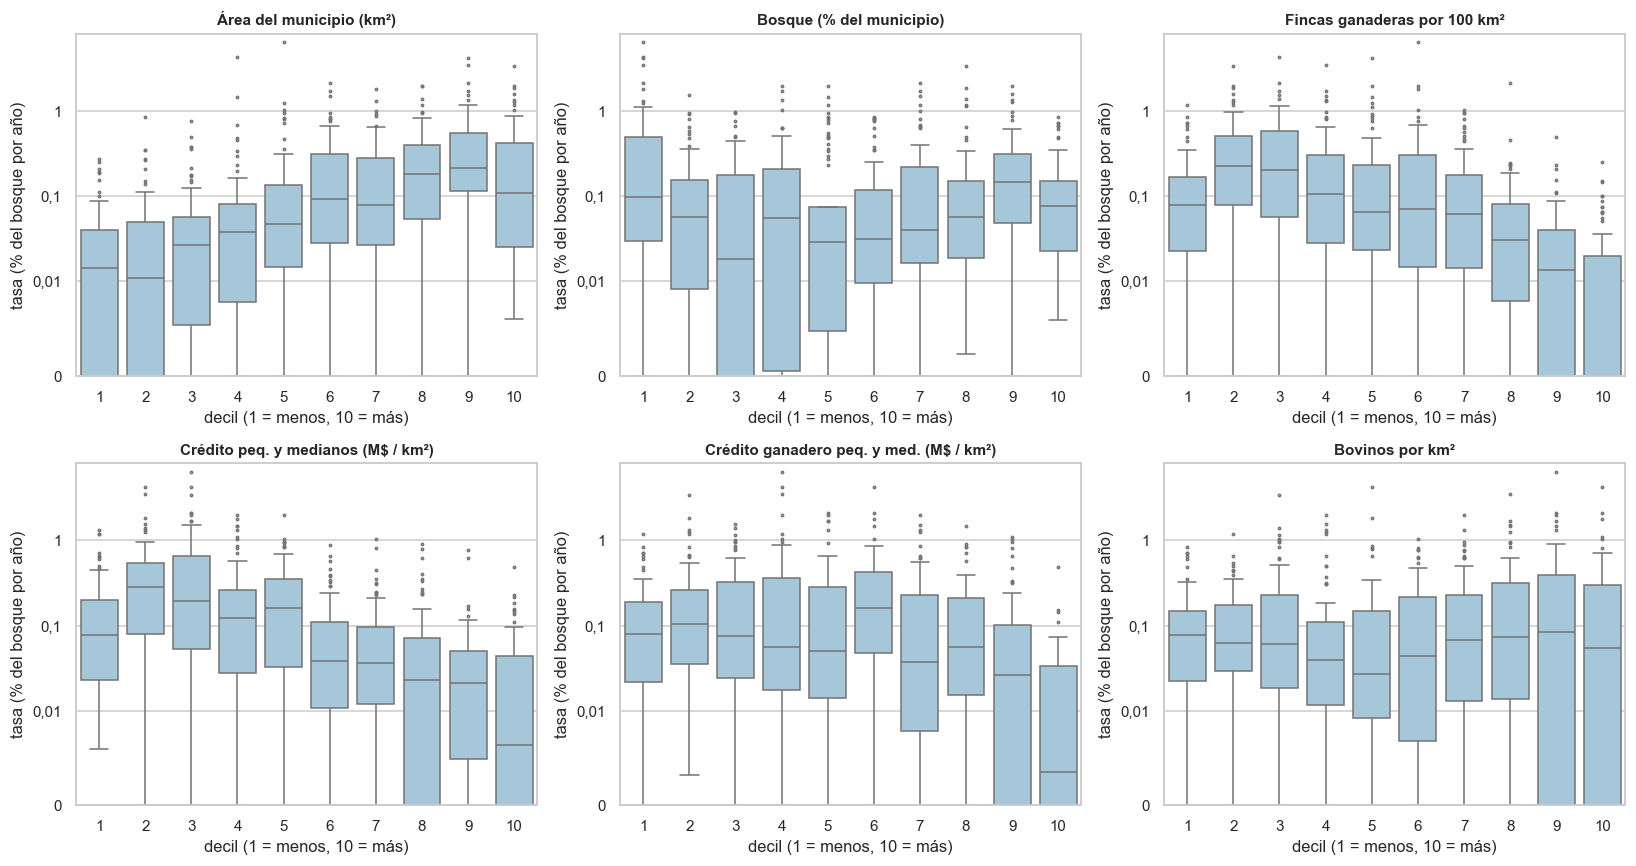

In [22]:
# Solo variables con pocos ceros: con muchos ceros (palma, cacao, cafe, arroz) los primeros deciles
# quedarian llenos de municipios iguales, repartidos al azar
seis = ["area", "bosque", "fincas", "cred_pm", "cred_gan", "bovinos"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, seis):
    p = municipios[[c, "tasa"]].dropna()
    p["decil"] = pd.qcut(p[c].rank(method="first"), 10, labels=range(1, 11))
    sns.boxplot(data=p, x="decil", y="tasa", color="#9ecae1", fliersize=1.5, ax=ax)
    eje_tasa(ax)
    ax.set(title=NOMBRES[c], xlabel="decil (1 = menos, 10 = más)", ylabel="tasa (% del bosque por año)")
plt.tight_layout()
plt.show()

<!-- lectura:8 -->
**Qué muestra.**

- **Área:** la tasa sube con el tamaño del municipio, de 0,014 % en el decil 1 a 0,21 % en el decil 9.
- **Fincas y crédito: una U invertida.** La tasa más alta está en los deciles 2 y 3: municipios con pocas fincas y
  poco crédito, pero no con cero. Con el crédito a pequeños y medianos, la mediana pasa de 0,08 % (decil 1) a 0,28 %
  (decil 2) y baja hasta 0,006 % (decil 10). Con las fincas, de 0,08 % a 0,23 % y después a 0.
- **Crédito ganadero:** parejo hasta el decil 6 y luego baja.
- **Bovinos y bosque:** no hay un patrón claro. Con los bovinos, la mediana se queda entre 0,03 % y 0,08 % en todos
  los deciles.
- **Una forma de leer la U.** Los municipios casi sin fincas ni crédito son selva apartada, adonde todavía no llega
  la actividad agropecuaria. Los que tienen un poco son la frontera: la actividad está entrando y se tumba bosque.
  Los que tienen mucho son zonas consolidadas, con poco bosque por tumbar. La correlación de la sección 7 solo ve la
  parte de bajada.

## 9. Componentes principales (PCA)

**La pregunta.** Las variables se parecen mucho entre sí (crédito, fincas y ganado suelen ir juntos). ¿Cuáles son
las pocas "direcciones" en que de verdad se diferencian los municipios?

**Cómo se hace.**

1. Se pasan las variables a escala logarítmica y se **estandarizan** (a cada una se le resta su promedio y se divide
   por su desviación), para que ninguna pese más solo por su unidad de medida.
2. El PCA encuentra los **componentes**: combinaciones de variables que recogen la mayor parte de las diferencias
   entre municipios. El primero recoge lo más posible; el segundo, lo más posible de lo que queda, y así.
3. La deforestación **no entra** al PCA: se mira después si se relaciona con los componentes.

**Cómo leer los gráficos.** A la izquierda, cuánta información recoge cada componente. A la derecha, las **cargas**:
qué tanto pesa cada variable en cada componente. Una carga alta y positiva quiere decir que el componente sube cuando
esa variable sube.

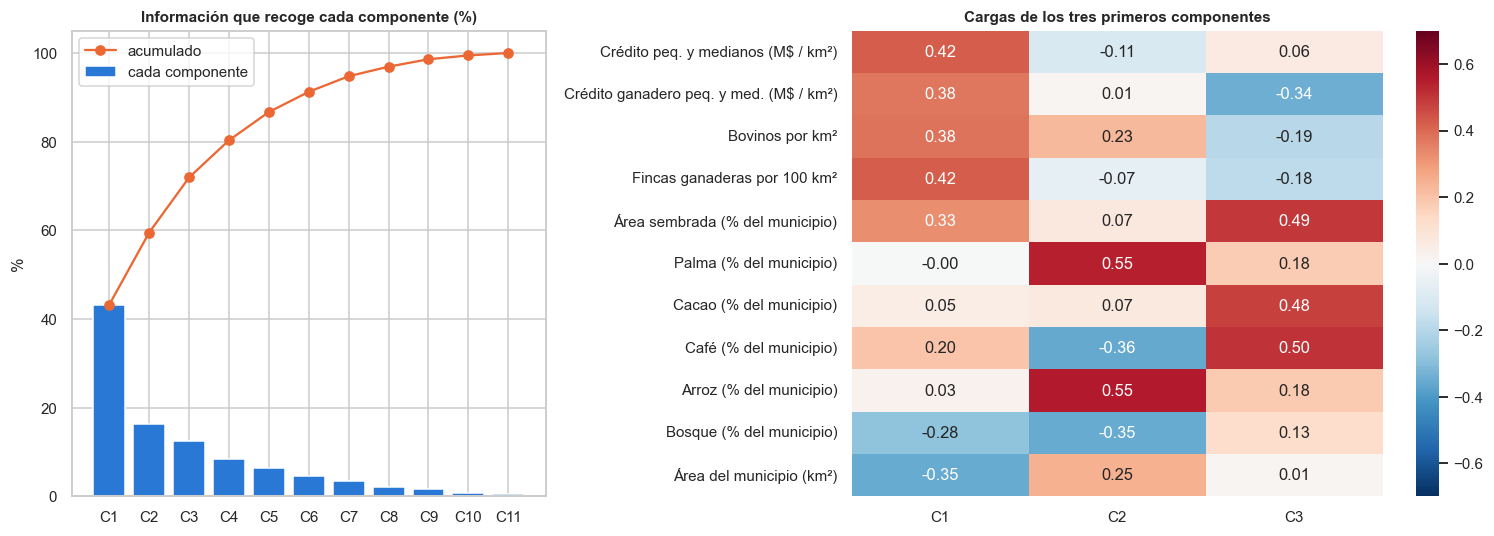

,información (%),acumulada (%),Spearman con la deforestación
C1,43.24,43.24,-0.41
C2,16.26,59.50,0.40
C3,12.42,71.92,0.11
C4,8.39,80.32,0.21


In [23]:
X = municipios[VARIABLES].copy()
X["area"] = np.log10(X.area)
X[VARIABLES[:-1]] = np.log1p(X[VARIABLES[:-1]])
X = X.dropna()
Z = StandardScaler().fit_transform(X)
pca = PCA().fit(Z)
puntajes = pd.DataFrame(pca.transform(Z), index=X.index, columns=[f"C{i + 1}" for i in range(len(VARIABLES))])
varianza = pd.Series(100 * pca.explained_variance_ratio_, index=puntajes.columns)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.4]})
a1.bar(varianza.index, varianza, color="#2a78d6", label="cada componente")
a1.plot(varianza.index, varianza.cumsum(), color="#eb6834", marker="o", label="acumulado")
a1.set(title="Información que recoge cada componente (%)", ylabel="%")
a1.legend()
cargas = pd.DataFrame(pca.components_[:3].T, index=[NOMBRES[c] for c in VARIABLES], columns=["C1", "C2", "C3"])
sns.heatmap(cargas, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-.7, vmax=.7, ax=a2)
a2.set_title("Cargas de los tres primeros componentes")
plt.tight_layout()
plt.show()
pd.DataFrame({"información (%)": varianza, "acumulada (%)": varianza.cumsum(),
              "Spearman con la deforestación": puntajes.corrwith(municipios.loc[X.index, "tasa"], method="spearman")}
             ).head(4).round(2)

<!-- lectura:9a -->
**Qué muestra.** Los dos primeros componentes recogen el 60 % de la información, y los cuatro primeros, el 80 %.

- **C1 (43 %): cuánta actividad agropecuaria hay por km².** Sube con el crédito, el crédito ganadero, los bovinos,
  las fincas y el área sembrada, y baja con el bosque y el tamaño del municipio. Un C1 bajo es un municipio grande y
  boscoso; uno alto, un municipio agropecuario. Su correlación con la deforestación es −0,41.
- **C2 (16 %): llanura con arroz y palma frente a montaña cafetera.** Sube con la palma y el arroz, y baja con el café
  y el bosque. Su correlación con la deforestación es +0,40.
- **C3 (12 %): agricultura frente a ganadería.** Sube con el área sembrada, el cacao y el café, y baja con el crédito
  ganadero. Casi no se relaciona con la deforestación (0,11).

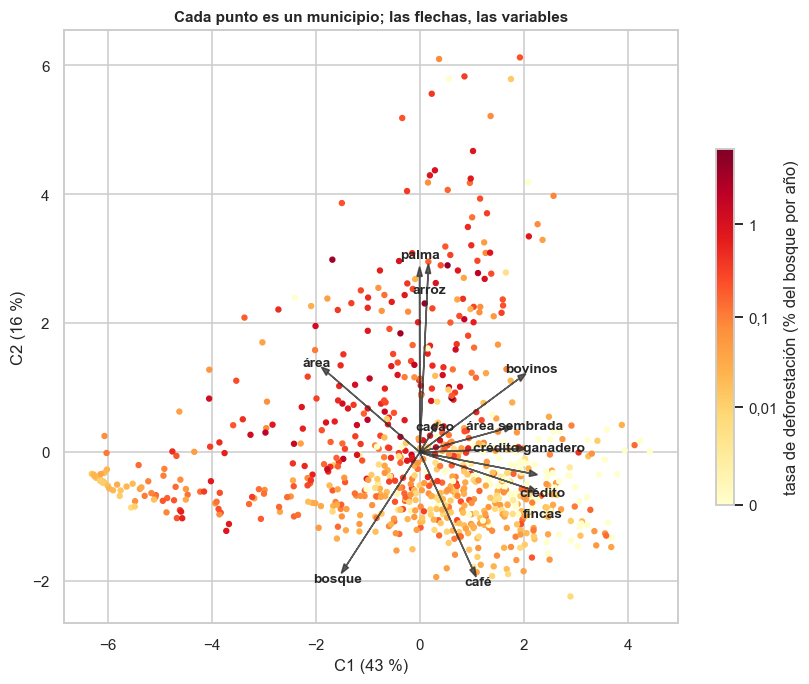

,municipios,bosque típico (%),tasa típica (%/año)
tramo de C1,,,
"(-7, -4]",62,90.527,0.055
"(-4, -2]",55,63.480,0.186
"(-2, 0]",196,33.411,0.144
"(0, 2]",353,18.493,0.039
"(2, 5]",110,13.852,0.008


In [24]:
fig, ax = plt.subplots(figsize=(9, 7))
puntos = ax.scatter(puntajes.C1, puntajes.C2, c=np.log10(municipios.loc[X.index, "tasa"] + 0.001), cmap="YlOrRd", s=10)
barra_tasa(puntos, ax)
ocupados = []
for i, c in enumerate(VARIABLES):
    x, y = 5 * pca.components_[0, i], 5 * pca.components_[1, i]
    ax.arrow(0, 0, x, y, color="#333", head_width=0.1, alpha=.8)
    tx, ty = 1.12 * x, 1.12 * y
    while any(abs(tx - a) < 1 and abs(ty - b) < 0.3 for a, b in ocupados):   # evita etiquetas encimadas
        ty -= 0.3
    ocupados.append((tx, ty))
    ax.text(tx, ty, CORTOS[c], fontsize=9, ha="center", va="center", weight="bold")
ax.set(title="Cada punto es un municipio; las flechas, las variables", xlabel=f"C1 ({varianza.C1:.0f} %)",
       ylabel=f"C2 ({varianza.C2:.0f} %)")
plt.show()

# La deforestacion a lo largo de C1, de lo mas boscoso (izquierda) a lo mas agropecuario (derecha)
t = municipios.loc[X.index].assign(C1=puntajes.C1)
(t.groupby(pd.cut(t.C1, [-7, -4, -2, 0, 2, 5]), observed=True)
 .agg(municipios=("tasa", "size"), **{"bosque típico (%)": ("bosque", "median"),
                                      "tasa típica (%/año)": ("tasa", "median")})
 .rename_axis("tramo de C1").round(3))

<!-- lectura:9b -->
**Qué muestra.** Las flechas apuntan hacia donde crece cada variable. Los puntos más rojos están en la mitad
izquierda y arriba: municipios donde se mezclan bosque y algo de actividad agropecuaria, o con arroz y palma. Los
puntos pálidos están abajo a la derecha (crédito, fincas y café: la zona andina) y en el extremo izquierdo (la selva
más apartada).

La tabla lo confirma recorriendo C1 de izquierda a derecha. En la selva más apartada (C1 ≤ −4, con 91 % de bosque) la
tasa típica es 0,055 %. En el tramo siguiente, con 63 % de bosque, sube a 0,19 %. Después baja hasta 0,008 % en los
municipios más agropecuarios (C1 > 2). Es la misma U invertida de la sección 8.

## 10. Grupos de municipios (k-medias)

**La pregunta.** ¿Hay tipos de municipios? ¿En cuáles se concentra la deforestación?

**Cómo se hace.**

1. Se usan las mismas variables estandarizadas del PCA. La deforestación no entra: los grupos se forman solo con
   crédito, ganado, cultivos, bosque y tamaño.
2. **K-medias** reparte los municipios en *k* grupos, de forma que cada municipio quede con los que más se le parecen.
3. Para elegir *k* se miran dos criterios:
   - **El codo**: cuánto se reduce la dispersión dentro de los grupos al agregar uno más. Se busca el punto donde
     agregar grupos deja de ayudar mucho.
   - **La silueta**: qué tan bien separado queda cada municipio de los otros grupos, de −1 a 1. Más alto es mejor.
4. Después se mira la deforestación de cada grupo y, **dentro de cada grupo**, cómo se relaciona con el resto de
   variables. Comparar municipios parecidos entre sí evita mezclar realidades muy distintas.

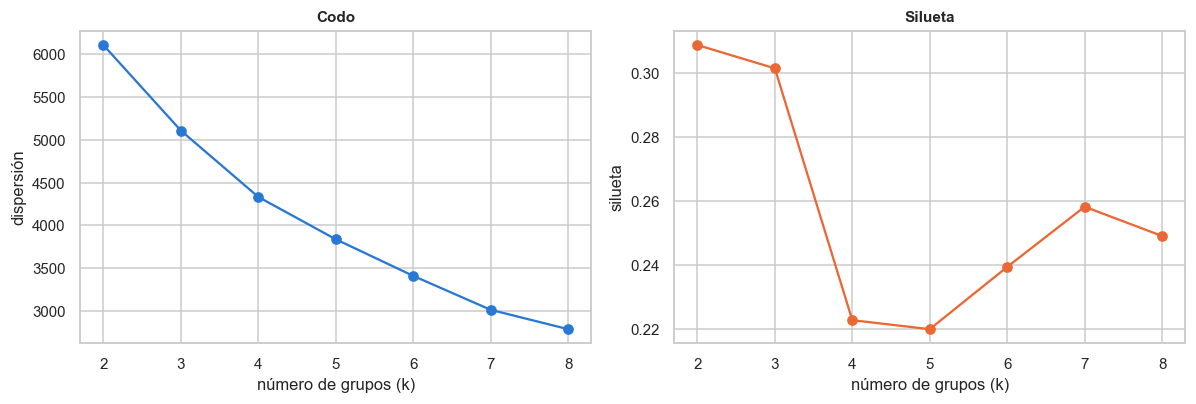

,dispersión dentro de los grupos,silueta
2,6110.282,0.309
3,5110.332,0.302
4,4333.619,0.223
5,3838.328,0.220
6,3410.219,0.240
7,3013.299,0.258
8,2786.835,0.249


In [25]:
ks = range(2, 9)
modelos = {k: KMeans(k, n_init=50, random_state=0).fit(Z) for k in ks}
criterios = pd.DataFrame({"dispersión dentro de los grupos": [modelos[k].inertia_ for k in ks],
                          "silueta": [silhouette_score(Z, modelos[k].labels_) for k in ks]}, index=list(ks))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
criterios.iloc[:, 0].plot(ax=a1, marker="o", color="#2a78d6")
a1.set(title="Codo", xlabel="número de grupos (k)", ylabel="dispersión")
criterios.silueta.plot(ax=a2, marker="o", color="#eb6834")
a2.set(title="Silueta", xlabel="número de grupos (k)", ylabel="silueta")
plt.tight_layout()
plt.show()
criterios.round(3)

<!-- lectura:10a -->
**Qué muestra.**

- El codo no tiene un punto de quiebre claro: la dispersión baja de forma pareja.
- La silueta es mayor con 2 o 3 grupos (0,31 y 0,30) que con 4 (0,22). Todos son valores bajos: los grupos se tocan,
  hay municipios a medio camino entre uno y otro, porque el paso de la selva a la zona andina es gradual.
- Se usan **4 grupos** porque son fáciles de interpretar y separan algo importante. Con 3 grupos, 211 de los 290
  municipios de frontera quedan revueltos con los andinos, y la frontera es donde ocurre buena parte de la
  deforestación. Al final de la sección se revisa que la conclusión principal no cambie con 2 o 3 grupos.

**Los grupos con k = 4.** K-medias numera los grupos sin ningún orden (0, 1, 2, 3). Para leerlos más fácil, cada
grupo recibe un nombre según su rasgo más marcado: el de más bosque se llama *Selva*, el de más café *Andino*, el de
más palma y arroz *Llanura con arroz y palma*, y el que queda, *Frontera*. Los nombres son una ayuda para leer; no
salen de los datos.

La tabla muestra el municipio típico (la mediana) de cada grupo.

In [26]:
K = 4
grupo = pd.Series(modelos[K].labels_, index=X.index)
medianas = municipios.loc[X.index, VARIABLES].groupby(grupo).median()
nombre_grupo = {medianas.bosque.idxmax(): "Selva",
                medianas.cafe.idxmax(): "Andino",
                (medianas.palma + medianas.arroz).idxmax(): "Llanura con arroz y palma"}
nombre_grupo.update({k: "Frontera" for k in range(K) if k not in nombre_grupo})
assert len(set(nombre_grupo.values())) == K, "dos reglas escogieron el mismo grupo"
ORDEN = ["Selva", "Frontera", "Llanura con arroz y palma", "Andino"]

g = municipios.join(grupo.map(nombre_grupo).rename("grupo"), how="inner")
perfil = g.groupby("grupo").agg(
    municipios=("tasa", "size"),
    **{"% de la deforestación": ("def_total_ha", "sum")},
    **{NOMBRES[c]: (c, "median") for c in ["tasa"] + VARIABLES}).loc[ORDEN]
perfil["% de la deforestación"] = 100 * perfil["% de la deforestación"] / g.def_total_ha.sum()
perfil.T.round(2)

grupo,Selva,Frontera,Llanura con arroz y palma,Andino
municipios,92.00,290.00,97.00,297.00
% de la deforestación,57.53,32.26,9.63,0.58
Deforestación IDEAM (% del bosque),0.09,0.12,0.24,0.02
Crédito peq. y medianos (M$ / km²),0.47,7.17,8.50,24.29
Crédito ganadero peq. y med. (M$ / km²),0.00,2.43,3.11,5.26
Bovinos por km²,0.21,29.45,59.26,45.10
Fincas ganaderas por 100 km²,1.24,84.00,78.67,211.20
Área sembrada (% del municipio),0.63,3.46,13.78,13.54
Palma (% del municipio),0.00,0.00,2.09,0.00
Cacao (% del municipio),0.03,0.07,0.18,0.00


<!-- lectura:10b -->
**Qué muestra.**

- **Selva** (92 municipios): 87 % de bosque, casi sin ganado (0,2 bovinos por km²) ni crédito. Son municipios enormes
  (2 825 km² el típico). Tiene el **58 %** de la deforestación, aunque su tasa típica es baja (0,09 %): pierde una
  parte pequeña de muchísimo bosque.
- **Frontera** (290): 30 % de bosque, 29 bovinos por km², algo de crédito. Tiene el **32 %** de la deforestación y
  una tasa típica de 0,12 %.
- **Llanura con arroz y palma** (97): 10 % de bosque y el más ganadero (59 bovinos por km²). Tiene la tasa típica más
  alta (0,24 %), pero solo el 10 % de las hectáreas: le queda poco bosque y lo pierde rápido.
- **Andino** (297): 18 % de bosque, café, muchas fincas (211 por 100 km²) y el crédito más alto (24 M$ por km²). Casi
  no deforesta: el 0,6 % del total, con una tasa típica de 0,02 %.

**¿Son firmes los grupos?** Si los grupos fueran un accidente de los datos, cambiarían mucho al quitar unos
cuantos municipios. Para probarlo se usa la misma idea del bootstrap: se repite k-medias 50 veces, cada vez con el
80 % de los municipios escogidos al azar, y se cuenta qué porcentaje de municipios queda en el mismo grupo que en el
resultado original.

In [27]:
rng = np.random.default_rng(3)
original = modelos[K].labels_
coinciden = []
for semilla in range(50):
    filas = rng.choice(len(Z), int(.8 * len(Z)), replace=False)
    nuevo = KMeans(K, n_init=10, random_state=semilla).fit(Z[filas]).predict(Z)
    # Los numeros de los grupos cambian de una corrida a otra: se toma la correspondencia que mas coincide
    coinciden.append(max((np.array(p)[nuevo] == original).mean() for p in permutations(range(K))))
coinciden = 100 * np.array(coinciden)
print(f"Municipios que quedan en el mismo grupo: {np.median(coinciden):.0f} % en la repetición típica, "
      f"{coinciden.min():.0f} % en la peor de las 50")

Municipios que quedan en el mismo grupo: 98 % en la repetición típica, 97 % en la peor de las 50


<!-- lectura:10e -->
**Qué muestra.** En la repetición típica, el 98 % de los municipios queda en el mismo grupo; en la peor, el 97 %.
Los grupos son firmes: no dependen de unos pocos municipios.

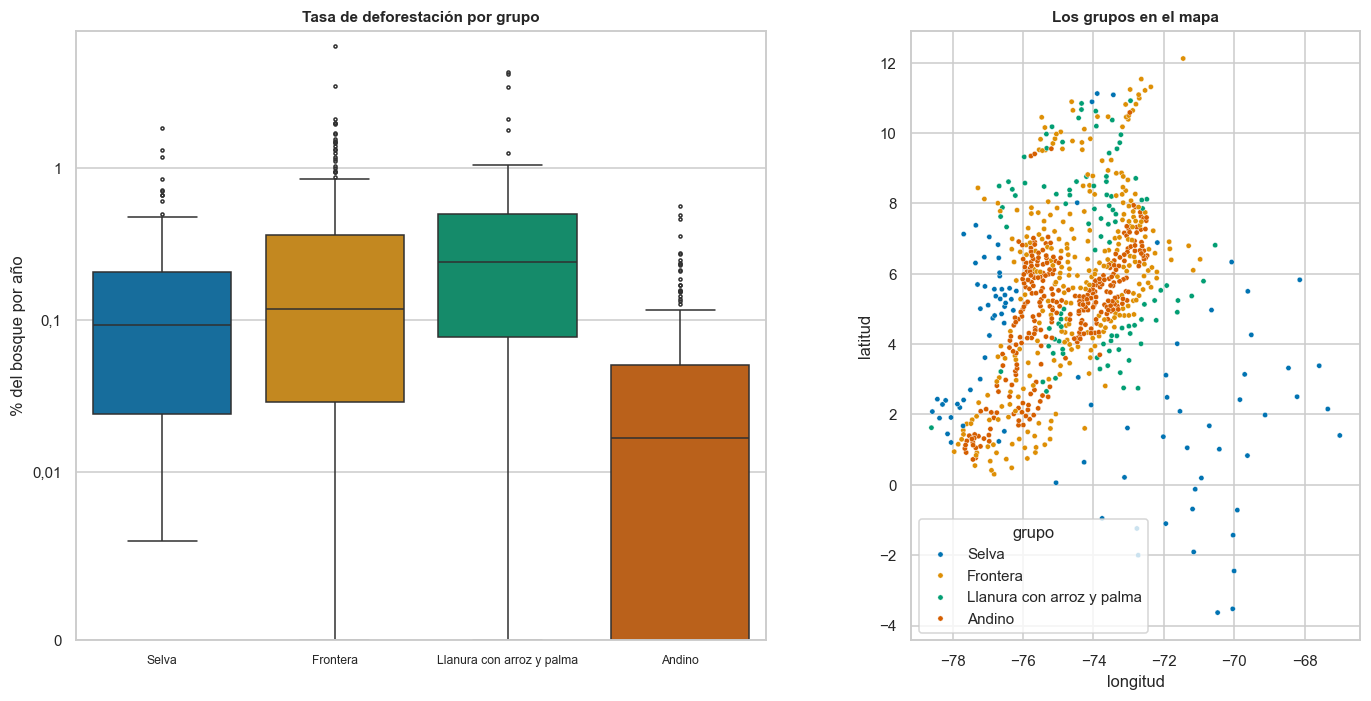

En qué regiones están los municipios de cada grupo (% del grupo):


region,Caribe,Pacífico,Eje cafetero,Centro Oriente,Centro Sur,Llano
grupo,,,,,,
Selva,4.0,47.0,2.0,1.0,16.0,29.0
Frontera,17.0,12.0,18.0,32.0,14.0,7.0
Llanura con arroz y palma,34.0,2.0,7.0,12.0,15.0,29.0
Andino,1.0,17.0,26.0,43.0,12.0,0.0


In [28]:
COLORES = dict(zip(ORDEN, sns.color_palette("colorblind", K)))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6.5), gridspec_kw={"width_ratios": [1, 1.1]})
sns.boxplot(data=g, x="grupo", y="tasa", order=ORDEN, palette=COLORES, fliersize=2, ax=a1)
eje_tasa(a1)
a1.set(title="Tasa de deforestación por grupo", xlabel="", ylabel="% del bosque por año")
a1.tick_params(axis="x", labelsize=8)
sns.scatterplot(data=g.dropna(subset=["lon", "lat"]), x="lon", y="lat", hue="grupo", hue_order=ORDEN,
                palette=COLORES, s=12, ax=a2)
a2.set_aspect("equal")
a2.set(title="Los grupos en el mapa", xlabel="longitud", ylabel="latitud")
plt.tight_layout()
plt.show()
print("En qué regiones están los municipios de cada grupo (% del grupo):")
pd.crosstab(g.grupo, g.region, normalize="index").mul(100).round(0).loc[ORDEN]

<!-- lectura:10c -->
**Qué muestra.**

- La Selva está en el Pacífico (47 %), el Llano (29 %) y Centro Sur (16 %): Chocó, la Orinoquía y la Amazonía.
- El Andino está en Centro Oriente (43 %) y el Eje cafetero (26 %).
- La Llanura con arroz y palma está en el Caribe (34 %) y el Llano (29 %).
- La Frontera está repartida por todo el país.
- En el boxplot, de mayor a menor tasa: Llanura, Frontera, Selva y Andino.

**Correlaciones dentro de cada grupo.** Es la misma correlación de la sección 7, pero calculada solo entre los
municipios de un mismo grupo. Así se compara la Selva con la Selva y la Frontera con la Frontera.

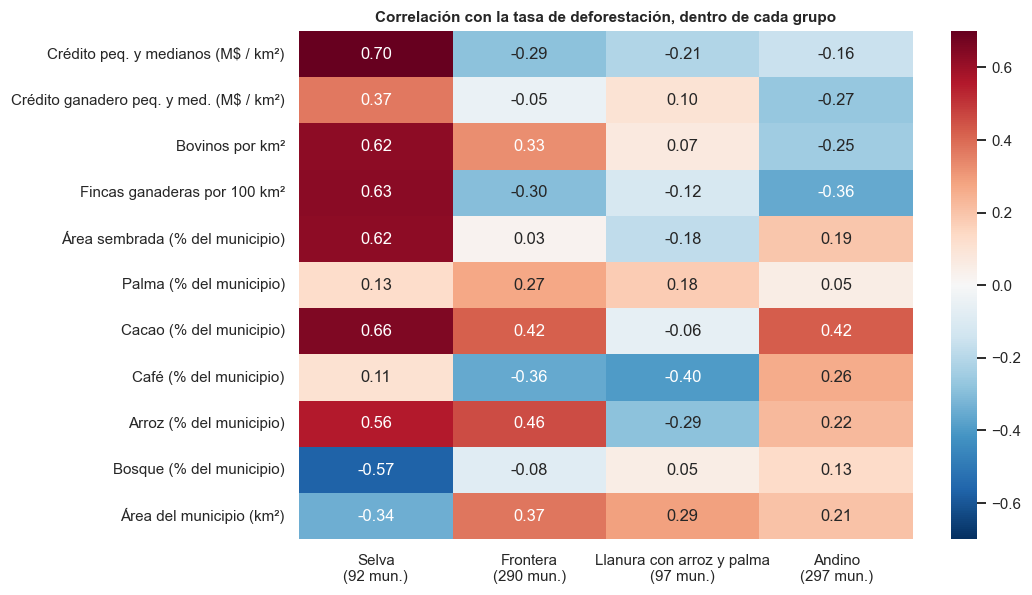

,a partir de qué valor la correlación cuenta
grupo,
Selva,0.21
Frontera,0.12
Llanura con arroz y palma,0.20
Andino,0.12


In [29]:
dentro = g.groupby("grupo").apply(lambda t: t[columnas].corr(method="spearman")["tasa"][VARIABLES]).T[ORDEN]
tamanos = g.groupby("grupo").size()[ORDEN]
dentro.columns = [f"{k}\n({n} mun.)" for k, n in tamanos.items()]
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(dentro.rename(index=NOMBRES), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-.7, vmax=.7, ax=ax)
ax.set(title="Correlación con la tasa de deforestación, dentro de cada grupo", xlabel="", ylabel="")
plt.show()
(2 / np.sqrt(tamanos)).round(2).rename("a partir de qué valor la correlación cuenta").to_frame()

<!-- lectura:10d -->
**Qué muestra.**

- **Selva.** Casi todo va con más deforestación: el crédito (0,70), el cacao (0,66), las fincas (0,63), los bovinos
  (0,62), el área sembrada (0,62), el arroz (0,56) y el crédito ganadero (0,37). Entre los municipios de selva,
  deforestan más aquellos adonde ya llegó la actividad agropecuaria. El bosque va al revés (−0,57).
- **Frontera.** Van con más deforestación el arroz (0,46), el cacao (0,42), el área (0,37), los bovinos (0,33) y la
  palma (0,27). Las fincas van al revés (−0,30): deforestan más los municipios con más ganado y menos fincas, lo que
  sugiere hatos más grandes por finca.
- **Llanura y Andino.** Hay otras relaciones (por ejemplo, el cacao en el Andino, 0,42), pero el ganado no va con más
  deforestación.
- **Esto cambia la lectura de la sección 7.** En el país entero, los bovinos daban cero. Dentro de la Selva dan 0,62 y
  dentro de la Frontera 0,33. El cero nacional sale de mezclar la zona andina, con mucho ganado y poca
  deforestación, con la selva y la frontera, donde más ganado sí va con más deforestación.

**¿Depende esto de haber escogido k = 4?** La silueta prefería 2 o 3 grupos. Para revisar que el resultado no
dependa de esa elección, se repite la cuenta con k = 2, 3 y 4, mirando siempre el grupo con más bosque.

In [30]:
filas = []
for k in (2, 3, 4):
    t = municipios.loc[X.index].assign(grupo=modelos[k].labels_)
    sel = t[t.grupo == t.groupby("grupo").bosque.median().idxmax()]
    filas.append({"k": k, "municipios en el grupo con más bosque": len(sel),
                  "% de la deforestación": 100 * sel.def_total_ha.sum() / t.def_total_ha.sum(),
                  "Spearman bovinos–tasa": sel.bovinos.corr(sel.tasa, method="spearman"),
                  "Spearman crédito ganadero–tasa": sel.cred_gan.corr(sel.tasa, method="spearman"),
                  "Spearman fincas–tasa": sel.fincas.corr(sel.tasa, method="spearman")})
pd.DataFrame(filas).set_index("k").round(2)

,municipios en el grupo con más bosque,% de la deforestación,Spearman bovinos–tasa,Spearman crédito ganadero–tasa,Spearman fincas–tasa
k,,,,,
2,163,86.03,0.54,0.37,0.38
3,152,80.25,0.56,0.38,0.39
4,92,57.53,0.62,0.37,0.63


<!-- lectura:10f -->
**Qué muestra.** Con 2, 3 o 4 grupos, el grupo con más bosque concentra entre el 58 % y el 86 % de la deforestación.
Dentro de él, los bovinos van con más deforestación (de 0,54 a 0,62), y lo mismo el crédito ganadero (0,37 a 0,38) y
las fincas (0,38 a 0,63). La conclusión no depende de haber escogido 4 grupos.

## 11. ¿Cuando algo cambia en un municipio, cambia su deforestación?

**La pregunta.** Hasta aquí se compararon municipios entre sí. Ahora la pregunta es otra: **dentro de un mismo
municipio**, ¿los años en que sube el ganado o el crédito son los años en que sube la deforestación?

**Cómo se hace.**

1. A cada valor se le resta el **promedio de su municipio**. Así queda solo cuánto se aleja ese año de lo normal en
   ese municipio, y desaparecen las diferencias entre municipios.
2. También se le resta el **promedio de su año**, para quitar lo que le pasó a todo el país ese año: por ejemplo,
   que en 2023 la deforestación bajó en casi todas partes.
3. Se calcula la correlación de Spearman entre lo que queda, con un intervalo por bootstrap. Aquí el bootstrap
   remuestrea **municipios completos**, con sus cinco años juntos.

**Cómo leer el gráfico.** Igual que el de la sección 7: si la línea cruza el cero, no hay relación detectable.

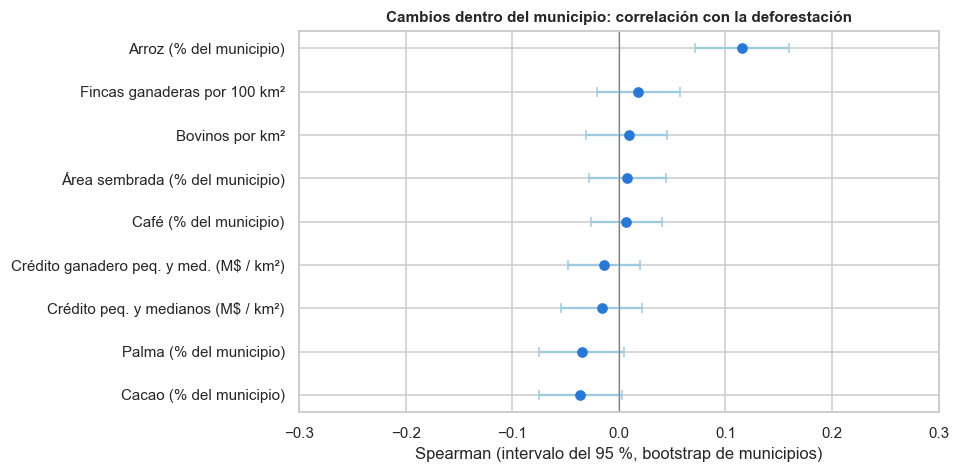

,Spearman,desde,hasta
Cacao (% del municipio),-0.037,-0.075,0.003
Palma (% del municipio),-0.034,-0.075,0.005
Crédito peq. y medianos (M$ / km²),-0.016,-0.054,0.021
Crédito ganadero peq. y med. (M$ / km²),-0.013,-0.047,0.020
Café (% del municipio),0.007,-0.026,0.040
Área sembrada (% del municipio),0.007,-0.028,0.044
Bovinos por km²,0.010,-0.031,0.046
Fincas ganaderas por 100 km²,0.018,-0.021,0.058
Arroz (% del municipio),0.115,0.072,0.160


In [31]:
cols = ["tasa"] + VARIABLES[:-2]   # el bosque y el area no cambian de un anio a otro
L = np.log1p(muestra[cols])
L[["cod_dane", "anio"]] = muestra[["cod_dane", "anio"]]
cambio = (L[cols] - L.groupby("cod_dane")[cols].transform("mean")
          - L.groupby("anio")[cols].transform("mean") + L[cols].mean())

filas_de = L.groupby("cod_dane").indices
ids = np.array(list(filas_de))
rng = np.random.default_rng(1)
base = cambio.corr(method="spearman")["tasa"][cols[1:]]
replicas = pd.DataFrame([
    cambio.iloc[np.concatenate([filas_de[i] for i in rng.choice(ids, len(ids))])]
    .corr(method="spearman")["tasa"][cols[1:]] for _ in range(500)])
cambios = pd.DataFrame({"Spearman": base, "desde": replicas.quantile(.025),
                        "hasta": replicas.quantile(.975)}).sort_values("Spearman")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(cambios.Spearman, range(len(cambios)),
            xerr=[cambios.Spearman - cambios.desde, cambios.hasta - cambios.Spearman],
            fmt="o", color="#2a78d6", ecolor="#9ecae1", capsize=3)
ax.set_yticks(range(len(cambios)), [NOMBRES[c] for c in cambios.index])
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlim(-0.3, 0.3)
ax.set(title="Cambios dentro del municipio: correlación con la deforestación",
       xlabel="Spearman (intervalo del 95 %, bootstrap de municipios)")
plt.show()
cambios.rename(index=NOMBRES).round(3)

<!-- lectura:11 -->
**Qué muestra.**

- Casi todo da cero: las correlaciones están entre −0,04 y 0,02 y los intervalos cruzan el cero. Dentro de un mismo
  municipio, los años con más crédito o más ganado que lo normal **no** van seguidos de más deforestación que lo
  normal.
- La excepción es el arroz: 0,12, con un intervalo de 0,07 a 0,16. Cuando un municipio sembró más arroz que lo
  normal, al año siguiente deforestó más que lo normal. Es una relación pequeña y es la única de nueve, así que
  conviene revisarla (en qué municipios pasa) antes de darle peso.

**¿Cuánto cambian las variables de un año a otro?** Para entender el resultado anterior, se mide qué parte de la
variación de cada variable es cambio de un año a otro dentro del mismo municipio. El resto son diferencias entre
municipios. Se calcula como la varianza de cada valor menos el promedio de su municipio, dividida por la varianza
total (en escala logarítmica).

In [32]:
dentro_mun = L[cols] - L.groupby("cod_dane")[cols].transform("mean")
(100 * dentro_mun.var() / L[cols].var()).rename(index=NOMBRES).round(1).rename("% de cambio año a año").to_frame()

,% de cambio año a año
Deforestación IDEAM (% del bosque),27.8
Crédito peq. y medianos (M$ / km²),2.6
Crédito ganadero peq. y med. (M$ / km²),5.1
Bovinos por km²,0.7
Fincas ganaderas por 100 km²,0.4
Área sembrada (% del municipio),1.1
Palma (% del municipio),0.3
Cacao (% del municipio),1.4
Café (% del municipio),0.2
Arroz (% del municipio),1.2


<!-- lectura:11b -->
**Qué muestra.** Las variables explicativas casi no cambian de un año a otro: el cambio año a año es el 0,7 % de la
variación de los bovinos, el 0,4 % de la de las fincas y el 2,6 % de la del crédito. Todo lo demás son diferencias
entre municipios. La deforestación, en cambio, se mueve bastante (28 %).

Con cinco años y variables tan quietas, hay muy poco movimiento para correlacionar. Por eso las secciones 7 a 10
dicen **dónde** se deforesta (en qué tipo de municipio), pero no **cuándo**.

## 12. ¿En qué meses se deforesta?

**La pregunta.** ¿Hay temporadas de deforestación? ¿El crédito sigue el mismo calendario?

**Cómo se hace.** Con la tabla mensual, se calcula qué porcentaje del total de cada año cae en cada mes, y se
promedia entre 2020 y 2025. Se hace para el país y para cada región.

**Cómo leer los gráficos.** Si todo se repartiera igual, cada mes tendría el 8,3 % del año (la línea punteada). Un
mes por encima de esa línea concentra más de lo normal.

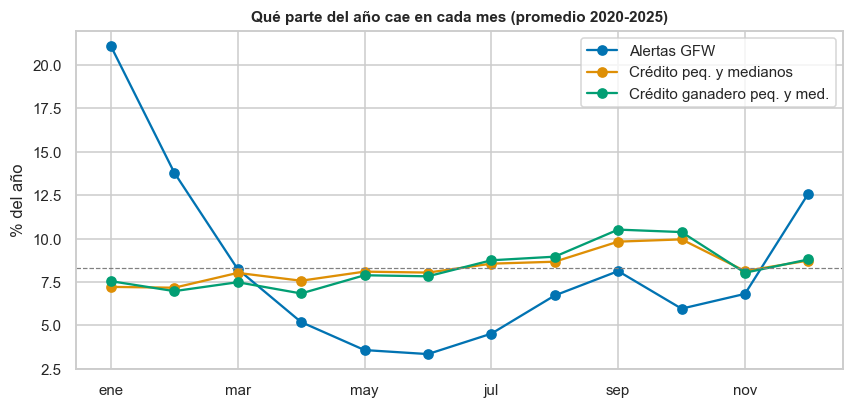

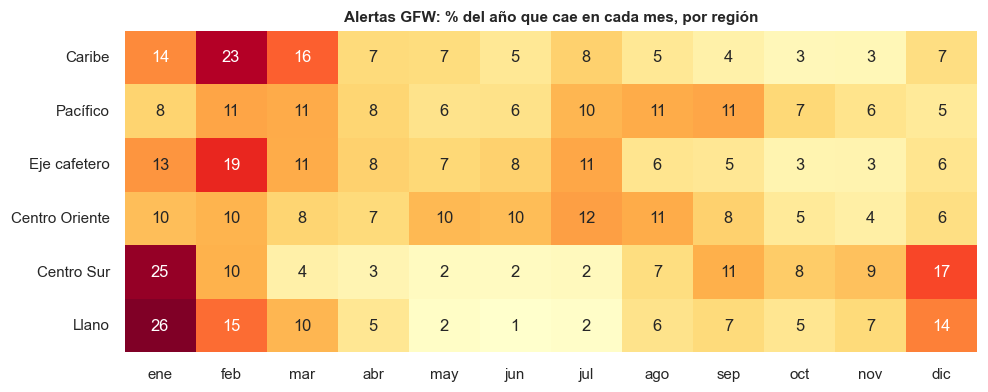

In [33]:
pais = mensual.groupby("mes")[["alertas_gfw_ha", "credito_pequeno_mediano_mm",
                               "credito_ganaderia_pequeno_mediano_mm"]].sum()
pais = pais[pais.index.year <= 2025]
reparto = (pais.groupby(pais.index.year).transform(lambda s: 100 * s / s.sum())
           .groupby(pais.index.month).mean())
MESES_TXT = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
reparto.index = MESES_TXT
reparto.columns = ["Alertas GFW", "Crédito peq. y medianos", "Crédito ganadero peq. y med."]

fig, ax = plt.subplots(figsize=(9, 4))
reparto.plot(ax=ax, marker="o")
ax.axhline(100 / 12, color="grey", lw=0.8, ls="--")
ax.set(title="Qué parte del año cae en cada mes (promedio 2020-2025)", ylabel="% del año")
plt.show()

m = mensual[mensual.mes.dt.year <= 2025].assign(anio=lambda t: t.mes.dt.year, m=lambda t: t.mes.dt.month)
region_mes = (m.groupby(["region", "anio", "m"]).alertas_gfw_ha.sum()
              .groupby(level=["region", "anio"]).transform(lambda s: 100 * s / s.sum())
              .groupby(level=["region", "m"]).mean().unstack())
region_mes.columns = MESES_TXT
fig, ax = plt.subplots(figsize=(10, 3.8))
sns.heatmap(region_mes, annot=True, fmt=".0f", cmap="YlOrRd", cbar=False, ax=ax)
ax.set(title="Alertas GFW: % del año que cae en cada mes, por región", xlabel="", ylabel="")
plt.show()

<!-- lectura:12 -->
**Qué muestra.**

- Las alertas se concentran en la temporada seca: enero (21 %), febrero (14 %) y diciembre (13 %) suman casi la mitad
  del año. Entre abril y julio bajan a 3–5 % por mes. Coincide con la temporada seca de la Orinoquía y la Amazonía,
  cuando se tumba y se quema. Una parte del pico puede venir también de que en la temporada seca hay menos nubes y
  los satélites ven mejor.
- La temporada es más marcada en el Llano (26 % en enero) y en Centro Sur (25 % en enero y 17 % en diciembre). En el
  Caribe y el Eje cafetero el pico es en febrero (23 % y 19 %). En el Pacífico y Centro Oriente las alertas se
  reparten más a lo largo del año.
- El crédito no sigue ese calendario: cada mes recibe entre 7 % y 10 %, con un poco más en septiembre y octubre.

## 13. ¿El crédito llega antes que la deforestación?

**La pregunta.** Si el crédito financiara la tala, se esperaría que suba unos meses **antes** que las alertas.
¿Pasa eso?

**Cómo se hace.** Una **correlación con rezagos**: se correlaciona el crédito de un mes con las alertas de *k* meses
después, para *k* entre −6 y 12. Antes hay que quitar tres cosas que confunden:

- **La estacionalidad.** Las alertas suben cada enero por la temporada seca, pase lo que pase con el crédito.
- **La tendencia.** Entre 2020 y 2025 el crédito subió y las alertas bajaron. Solo por eso saldrían correlaciones
  negativas en todos los rezagos, aunque una cosa no tenga que ver con la otra.
- **Las diferencias entre municipios** (en la versión municipal).

Se hace a dos escalas:

- **País.** A cada mes se le resta el promedio de su mes del año (el de todos los eneros, por ejemplo) y el promedio
  de su año.
- **Municipio.** A cada municipio-mes se le resta el promedio de su municipio y el promedio de ese mes en todos los
  municipios (por ejemplo, enero de 2023). Eso quita a la vez la estacionalidad y la tendencia del país. El
  intervalo se saca con bootstrap de municipios.

Se usan los meses de 2020 a 2025.

**Cómo leer el gráfico.** El eje horizontal es *k*: cuántos meses va el crédito **adelante** de las alertas (un
valor negativo quiere decir que va detrás). Si el crédito anticipara la deforestación, aparecería un pico positivo
con *k* mayor que cero. La banda gris del gráfico del país marca dónde la correlación no se distingue de cero.

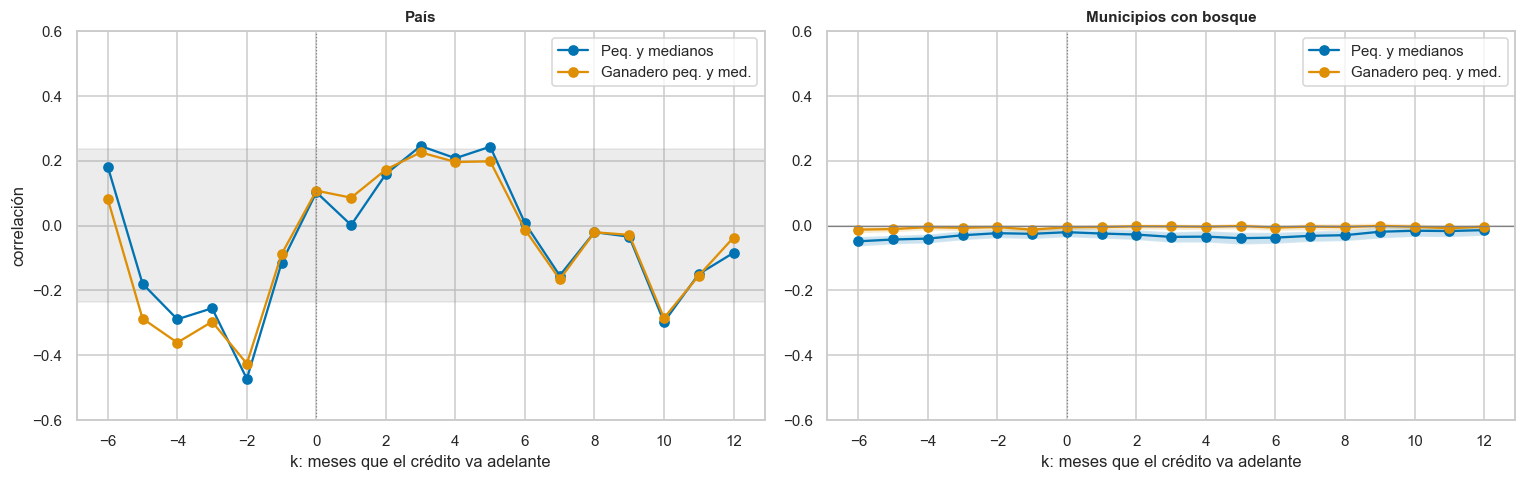

país                           municipios                     
    Peq. y medianos Ganadero peq. y med. Peq. y medianos Ganadero peq. y med.
-6            0.181                0.081          -0.049               -0.013
-5           -0.179               -0.287          -0.043               -0.011
-4           -0.289               -0.361          -0.040               -0.005
-3           -0.255               -0.296          -0.030               -0.007
-2           -0.472               -0.426          -0.024               -0.005
-1           -0.115               -0.088          -0.026               -0.013
 0            0.102                0.107          -0.020               -0.005
 1            0.001                0.086          -0.025               -0.005
 2            0.159                0.172          -0.028               -0.002
 3            0.245                0.225          -0.035               -0.003
 4            0.207                0.196          -0.034               -0.004
 5            0.243                0.198          -0.039               -0.002
 6            0.008               -0.012          -0.037               -0.006
 7           -0.154               -0.166          -0.032               -0.003
 8           -0.020               -0.021          -0.030               -0.005
 9           -0.034               -0.029          -0.019               -0.001
 10          -0.297               -0.285          -0.016               -0.004
 11          -0.149               -0.154          -0.017               -0.008
 12          -0.084               -0.037          -0.014               -0.003

In [34]:
rezagos = range(-6, 13)


def limpia_pais(serie):
    # log(1+x) sin el promedio de su mes del anio (estacionalidad) ni el de su anio (tendencia)
    s = np.log1p(serie)
    s = s - s.groupby(s.index.month).transform("mean")
    return s - s.groupby(s.index.year).transform("mean")


alertas_pais = limpia_pais(pais.alertas_gfw_ha.rename(None))
pais_rezagos = pd.DataFrame({nombre: [alertas_pais.corr(limpia_pais(pais[c]).shift(k)) for k in rezagos]
                             for c, nombre in (("credito_pequeno_mediano_mm", "Peq. y medianos"),
                                               ("credito_ganaderia_pequeno_mediano_mm", "Ganadero peq. y med."))},
                            index=list(rezagos))

mm = mensual[mensual.cod_dane.isin(municipios.index) & (mensual.mes.dt.year <= 2025)]


def tabla(col):
    # Matriz municipio x mes, en log(1+x), sin el promedio del municipio (fila) ni el del mes (columna)
    a = np.log1p(mm.pivot(index="cod_dane", columns="mes", values=col).values)
    return a - a.mean(1, keepdims=True) - a.mean(0, keepdims=True) + a.mean()


A = tabla("alertas_gfw_ha")
rng = np.random.default_rng(2)
municipal = {}
for c, nombre in (("credito_pequeno_mediano_mm", "Peq. y medianos"),
                  ("credito_ganaderia_pequeno_mediano_mm", "Ganadero peq. y med.")):
    Cm = tabla(c)

    def correlacion(filas, k):
        a, x = A[filas], Cm[filas]
        a, x = (a[:, k:], x[:, :x.shape[1] - k]) if k >= 0 else (a[:, :k], x[:, -k:])
        return np.corrcoef(a.ravel(), x.ravel())[0, 1]

    todas = np.arange(A.shape[0])
    boot = np.array([[correlacion(f, k) for k in rezagos]
                     for f in (rng.choice(todas, len(todas)) for _ in range(200))])
    municipal[nombre] = pd.DataFrame({"r": [correlacion(todas, k) for k in rezagos],
                                      "desde": np.percentile(boot, 2.5, 0),
                                      "hasta": np.percentile(boot, 97.5, 0)}, index=list(rezagos))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
pais_rezagos.plot(ax=a1, marker="o")
banda = 2 / np.sqrt(len(alertas_pais))
a1.axhspan(-banda, banda, color="grey", alpha=.15)
a1.set(title="País", xlabel="k: meses que el crédito va adelante", ylabel="correlación", ylim=(-.6, .6))
for nombre, t in municipal.items():
    a2.plot(t.index, t.r, marker="o", label=nombre)
    a2.fill_between(t.index, t.desde, t.hasta, alpha=.2)
a2.axhline(0, color="grey", lw=0.8)
a2.set(title="Municipios con bosque", xlabel="k: meses que el crédito va adelante", ylim=(-.6, .6))
a2.legend()
for ax in (a1, a2):
    ax.set_xticks(range(-6, 13, 2))
    ax.axvline(0, color="grey", lw=0.8, ls=":")
plt.tight_layout()
plt.show()
pd.concat({"país": pais_rezagos, "municipios": pd.DataFrame({n: t.r for n, t in municipal.items()})}, axis=1).round(3)

<!-- lectura:13 -->
**Qué muestra.**

- **País.** Las correlaciones suben y bajan sin un patrón claro: hay valores negativos fuertes cuando el crédito va
  detrás de las alertas (−0,47 con k = −2) y un bulto positivo pequeño con el crédito 3 a 5 meses adelante (0,20 a
  0,25, en el borde de la banda). Con solo 72 meses, y con meses seguidos que se parecen entre sí, estas oscilaciones
  son esperables; la banda gris supone meses independientes y por eso es optimista. No se leen como evidencia.
- **Municipios.** Con 777 municipios el resultado es claro: en todos los rezagos la correlación está entre −0,05 y 0.
  Un mes con más crédito que lo normal en un municipio no va seguido de más alertas en los meses siguientes.
- A escala mensual, no hay señal de que el crédito llegue antes que la deforestación.

<!-- lectura:conclusiones -->
## 14. Conclusiones

1. **La deforestación está muy concentrada.** El Gini es 0,91: 10 municipios suman la mitad, y el Llano y Centro
   Sur, el 71 %. Casi todo pasa en el arco amazónico.
2. **El IDEAM y GFW coinciden en dónde se deforesta** (Spearman 0,81, Lin 0,78). GFW suma 30 % más y marca alertas
   en municipios donde el IDEAM no ve deforestación.
3. **Hay que comparar por km².** En totales, todo crece con el tamaño del municipio.
4. **En el país entero**, deforestan más los municipios grandes y los que tienen arroz, cacao o palma, y menos los
   que tienen mucho crédito, muchas fincas y café. Los bovinos no se relacionan con la deforestación. En los cultivos
   pesa sobre todo tenerlos o no: un municipio con arroz pierde, típicamente, ocho veces más bosque que uno sin arroz.
   Estas correlaciones son estables año por año y se miden con Spearman, porque con Pearson unos pocos municipios
   extremos dominan el resultado.
5. **El crédito, las fincas y el ganado van muy juntos** (0,7 a 0,8), **y en contra del bosque**, en todas las
   regiones. Con correlaciones no se puede separar el papel de cada uno. En cambio, el arroz y el cacao se relacionan
   distinto según la región: en el Llano van con el ganado y el crédito; en el Pacífico, con el bosque.
6. **La medida de deforestación importa.** Con hectáreas por km² en lugar de la tasa, el bosque sale positivo (0,48)
   y los bovinos negativos (−0,28), porque esa medida refleja sobre todo dónde queda bosque.
7. **Con las fincas y el crédito la relación es una U invertida.** La tasa más alta está en los municipios con un
   poco de actividad agropecuaria: la frontera.
8. **Al separar tipos de municipio aparece el ganado.** Dentro de la Selva y la Frontera, que suman el 90 % de la
   deforestación, más bovinos van con más deforestación (0,62 y 0,33). En la Selva también el crédito y las fincas.
   Lo mismo pasa en la región del Llano (bovinos 0,47). El resultado se mantiene con 2, 3 o 4 grupos.
9. **En el tiempo no se ve casi nada.** Dentro de un mismo municipio, los cambios de un año a otro en crédito o
   ganado no van con cambios en la deforestación; solo el arroz muestra una relación pequeña. Estas variables casi no
   cambian en cinco años.
10. **La deforestación tiene temporada** (diciembre a febrero) **y el crédito no.** A escala mensual, el crédito no
   anticipa las alertas.
11. **Todo esto son asociaciones.** Dicen en qué tipo de municipio se deforesta, no qué causa la deforestación.

**Pendiente.** Confirmar con Jairo si el municipio de FINAGRO es el de la inversión o el del domicilio del productor.
Si es el del domicilio, parte del crédito puede estar asignada al municipio equivocado.